# Project FDA Lab Final: Heart Disease Prediction

## 1. Introduction

### 1.1 Problem Definition
Heart disease remains a leading cause of mortality worldwide, posing a significant public health challenge. The ability to accurately predict an individual's risk of developing heart disease is crucial for early intervention, personalized treatment, and improving patient outcomes. Currently, diagnosis often relies on a combination of clinical assessments, medical history, and various diagnostic tests, which can sometimes be subjective or delayed.

### 1.2 Who It Affects
Heart disease affects a broad spectrum of the population, regardless of age, gender, or socioeconomic status. Individuals with pre-existing conditions like diabetes, hypertension, or high cholesterol are particularly vulnerable. Furthermore, lifestyle factors such as diet, physical activity, smoking, and stress significantly contribute to risk. The impact extends beyond patients to their families, healthcare providers, and the broader economy due to healthcare costs and productivity loss.

### 1.3 Why a Solution is Needed
The urgent need for a robust heart disease prediction system stems from several factors:

*   **Early Detection:** Identifying high-risk individuals before the onset of severe symptoms allows for timely preventive measures and lifestyle modifications, which can dramatically alter disease progression.
*   **Resource Optimization:** Efficiently allocating healthcare resources by focusing on those most likely to benefit from interventions.
*   **Personalized Medicine:** Tailoring treatment plans based on individual risk profiles, moving away from a one-size-fits-all approach.
*   **Cost Reduction:** Preventing advanced-stage heart disease reduces the need for expensive and invasive treatments.
*   **Improved Quality of Life:** Proactive management can significantly enhance the quality of life for at-risk individuals.

In [89]:
# Install the ucimlrepo library to fetch UCI datasets
%pip install ucimlrepo

In [90]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)

# Display the first 5
print("First 5 rows of the Heart Disease dataset:")
display(df.head())

First 5 rows of the Heart Disease dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [91]:
# Display basic information about the dataset
print("\nInformation about the Heart Disease dataset:")
df.info()


Information about the Heart Disease dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [92]:
# Display descriptive statistics
print("\nDescriptive statistics of the Heart Disease dataset:")
display(df.describe())


Descriptive statistics of the Heart Disease dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


## 4. Exploratory Data Analysis (EDA)

### 4.1 Feature Description

The dataset contains the following features related to heart disease:

*   **age**: Age of the patient (in years)
*   **sex**: Sex of the patient (1 = male; 0 = female)
*   **cp**: Chest pain type (1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic)
*   **trestbps**: Resting blood pressure (in mm Hg on admission to the hospital)
*   **chol**: Serum cholestoral (in mg/dl)
*   **fbs**: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
*   **restecg**: Resting electrocardiographic results (0 = normal; 1 = having ST-T wave abnormality; 2 = showing probable or definite left ventricular hypertrophy)
*   **thalach**: Maximum heart rate achieved
*   **exang**: Exercise induced angina (1 = yes; 0 = no)
*   **oldpeak**: ST depression induced by exercise relative to rest
*   **slope**: The slope of the peak exercise ST segment (1 = upsloping; 2 = flat; 3 = downsloping)
*   **ca**: Number of major vessels (0-3) colored by flourosopy
*   **thal**: Thallium stress test result (3 = normal; 6 = fixed defect; 7 = reversible defect)
*   **num**: Diagnosis of heart disease (angiographic disease status) (0 = no disease; 1 = < 50% diameter narrowing; 2 = > 50% diameter narrowing) - *This is our target variable, we will simplify it to 0 = no disease, 1 = disease.*

### 3.1 Handling Missing Values

Based on the `df.info()` output, we identified missing values in the `ca` and `thal` columns. We will impute these missing values using the mode (most frequent value) for each column, as these are considered categorical or ordinal features. Then, we will check again if there are still missing values.

In [93]:
# Check for missing values before imputation
print("Missing values before imputation:")
print(df.isnull().sum())

# Impute missing values in 'ca' and 'thal' with the mode
for column in ['ca', 'thal']:
    mode_value = df[column].mode()[0]
    df[column].fillna(mode_value, inplace=True)

# Verify that missing values have been handled
print("\nMissing values after imputation:")
print(df.isnull().sum())

# Display basic information about the dataset after imputation
print("\nInformation about the Heart Disease dataset after imputation:")
df.info()

Missing values before imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Information about the Heart Disease dataset after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int

/tmp/ipykernel_17762/1244464649.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mode_value, inplace=True)


## 2. Exploratory Data Analysis (EDA)

### 2.1 Feature Description

The dataset contains the following features related to heart disease:

*   **age**: Age of the patient (in years)
*   **sex**: Sex of the patient (1 = male; 0 = female)
*   **cp**: Chest pain type (1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic)
*   **trestbps**: Resting blood pressure (in mm Hg on admission to the hospital)
*   **chol**: Serum cholestoral (in mg/dl)
*   **fbs**: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
*   **restecg**: Resting electrocardiographic results (0 = normal; 1 = having ST-T wave abnormality; 2 = showing probable or definite left ventricular hypertrophy)
*   **thalach**: Maximum heart rate achieved
*   **exang**: Exercise induced angina (1 = yes; 0 = no)
*   **oldpeak**: ST depression induced by exercise relative to rest
*   **slope**: The slope of the peak exercise ST segment (1 = upsloping; 2 = flat; 3 = downsloping)
*   **ca**: Number of major vessels (0-3) colored by flourosopy
*   **thal**: Thallium stress test result (3 = normal; 6 = fixed defect; 7 = reversible defect)
*   **num**: Diagnosis of heart disease (angiographic disease status) (0 = no disease; 1 = < 50% diameter narrowing; 2 = > 50% diameter narrowing) - *This is our target variable, we will simplify it to 0 = no disease, 1 = disease.*

### 2.2 Handling Missing Values

Based on the `df.info()` output, we identified missing values in the `ca` and `thal` columns. We will impute these missing values using the mode (most frequent value) for each column, as these are considered categorical or ordinal features. Then, we will check again if there are still missing values.

In [94]:
# Check for missing values before imputation
print("Missing values before imputation:")
print(df.isnull().sum())

# Impute missing values in 'ca' and 'thal' with the mode
for column in ['ca', 'thal']:
    mode_value = df[column].mode()[0]
    df[column] = df[column].fillna(mode_value)

# Verify that missing values have been handled
print("\nMissing values after imputation:")
print(df.isnull().sum())

# Display basic information about the dataset after imputation
print("\nInformation about the Heart Disease dataset after imputation:")
df.info()

Missing values before imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

Information about the Heart Disease dataset after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int

### 3.2 Feature Engineering and Target Binarization

To prepare the data for machine learning models, it's crucial to convert categorical features into a numerical format. We will use one-hot encoding for this purpose. Additionally, the target variable `num` currently has multiple classes (0, 1, 2, 3, 4) indicating different degrees of heart disease. For a binary classification problem, we will binarize it: `0` will represent no disease, and `1` will represent the presence of any heart disease.

In [95]:
# Identify categorical columns for one-hot encoding
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Binarize the target variable 'num'
# 0 = no disease, any other value (1, 2, 3, 4) = disease
df_encoded['target'] = df_encoded['num'].apply(lambda x: 1 if x > 0 else 0)

# Drop the original 'num' column as we now have 'target'
df_final = df_encoded.drop('num', axis=1)

# Display the first few rows of the preprocessed DataFrame and its information
print("First 5 rows of the preprocessed dataset:")
display(df_final.head())
print("\nInformation about the preprocessed dataset:")
df_final.info()

First 5 rows of the preprocessed dataset:


,age,trestbps,chol,thalach,oldpeak,sex_1,cp_2,cp_3,cp_4,fbs_1,...,restecg_2,exang_1,slope_2,slope_3,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0,target
0,63,145,233,150,2.3,True,False,False,False,True,...,True,False,False,True,False,False,False,True,False,0
1,67,160,286,108,1.5,True,False,False,True,False,...,True,True,True,False,False,False,True,False,False,1
2,67,120,229,129,2.6,True,False,False,True,False,...,True,True,True,False,False,True,False,False,True,1
3,37,130,250,187,3.5,True,False,True,False,False,...,False,False,False,True,False,False,False,False,False,0
4,41,130,204,172,1.4,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,0



Information about the preprocessed dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        303 non-null    int64  
 1   trestbps   303 non-null    int64  
 2   chol       303 non-null    int64  
 3   thalach    303 non-null    int64  
 4   oldpeak    303 non-null    float64
 5   sex_1      303 non-null    bool   
 6   cp_2       303 non-null    bool   
 7   cp_3       303 non-null    bool   
 8   cp_4       303 non-null    bool   
 9   fbs_1      303 non-null    bool   
 10  restecg_1  303 non-null    bool   
 11  restecg_2  303 non-null    bool   
 12  exang_1    303 non-null    bool   
 13  slope_2    303 non-null    bool   
 14  slope_3    303 non-null    bool   
 15  ca_1.0     303 non-null    bool   
 16  ca_2.0     303 non-null    bool   
 17  ca_3.0     303 non-null    bool   
 18  thal_6.0   303 non-null    bool   
 19  thal_

### 4.2 Further Exploratory Data Analysis (EDA) and Visualization

#### 4.2.1 Target Variable Distribution

Let's examine the distribution of our target variable (`target`) to see if the classes are balanced.

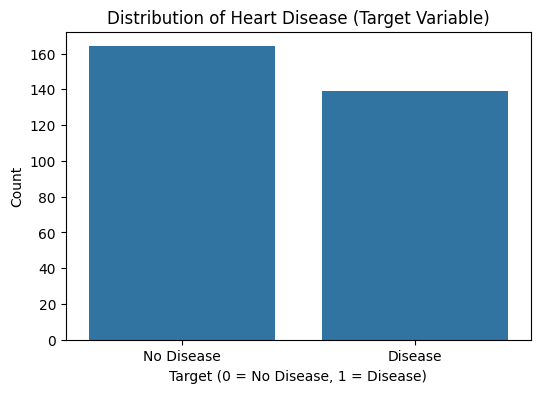

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_final)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Disease', 'Disease'])
plt.show()

#### 4.2.2 Distribution of Numerical Features

We will visualize the distribution of numerical features using histograms to understand their spread and detect any outliers or skewness.

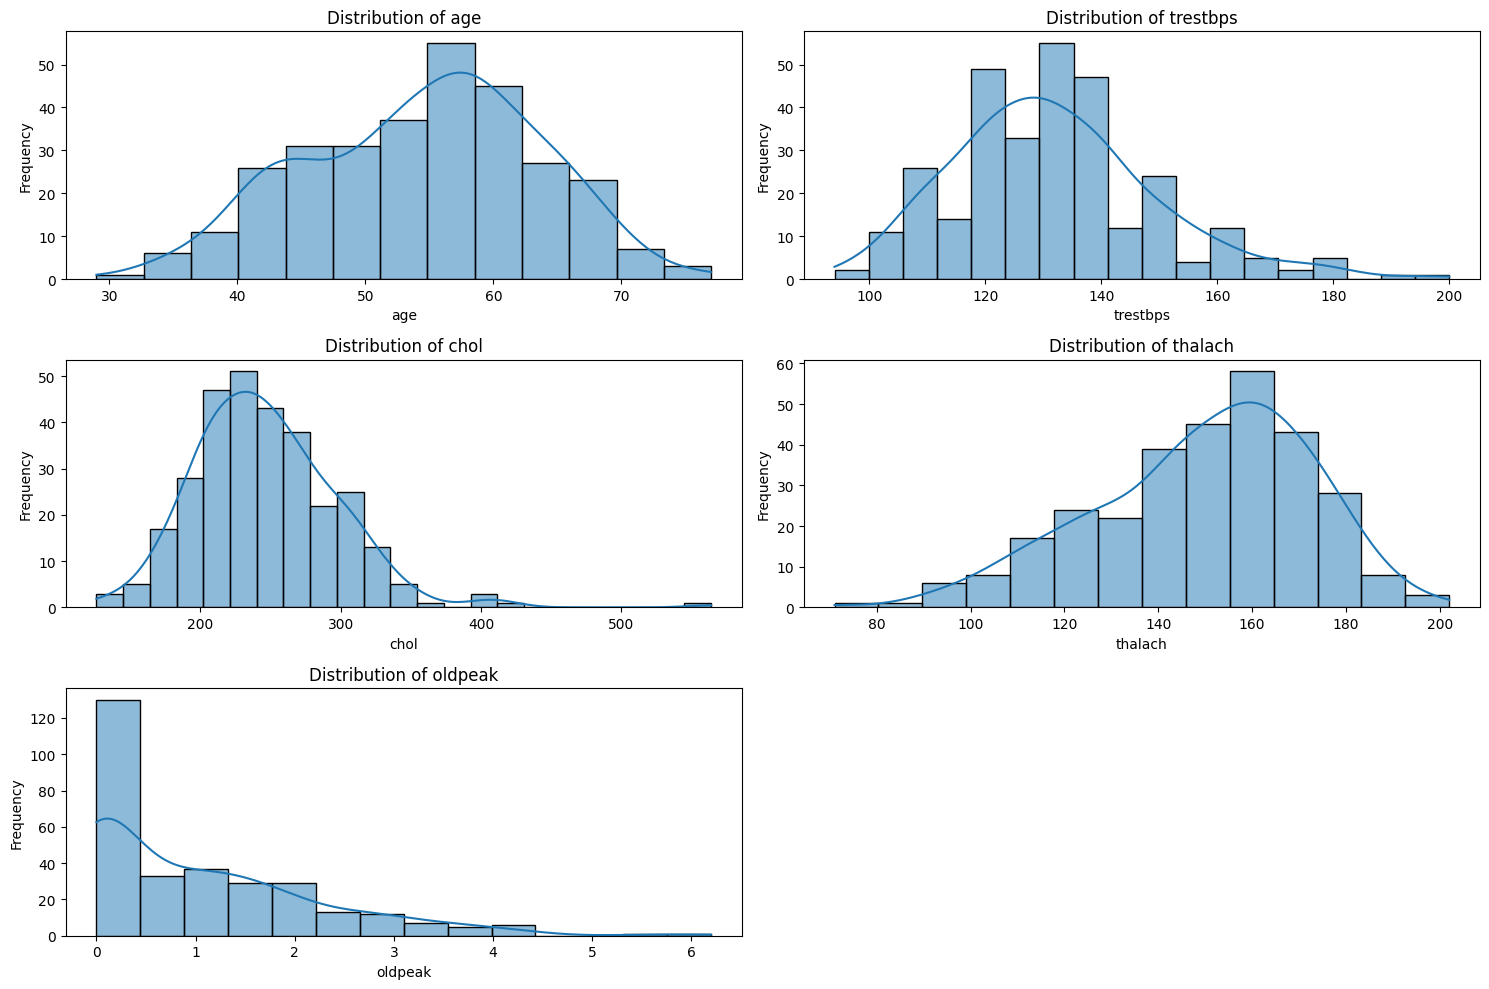

In [97]:
import math

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    # Using a 2-column grid: rows = ceil(total/2)
    plt.subplot(math.ceil(len(numerical_features)/2), 2, i + 1)
    sns.histplot(df_final[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### 2.4.3 Distribution of Categorical Features

We will use count plots to visualize the distribution of our one-hot encoded categorical features.

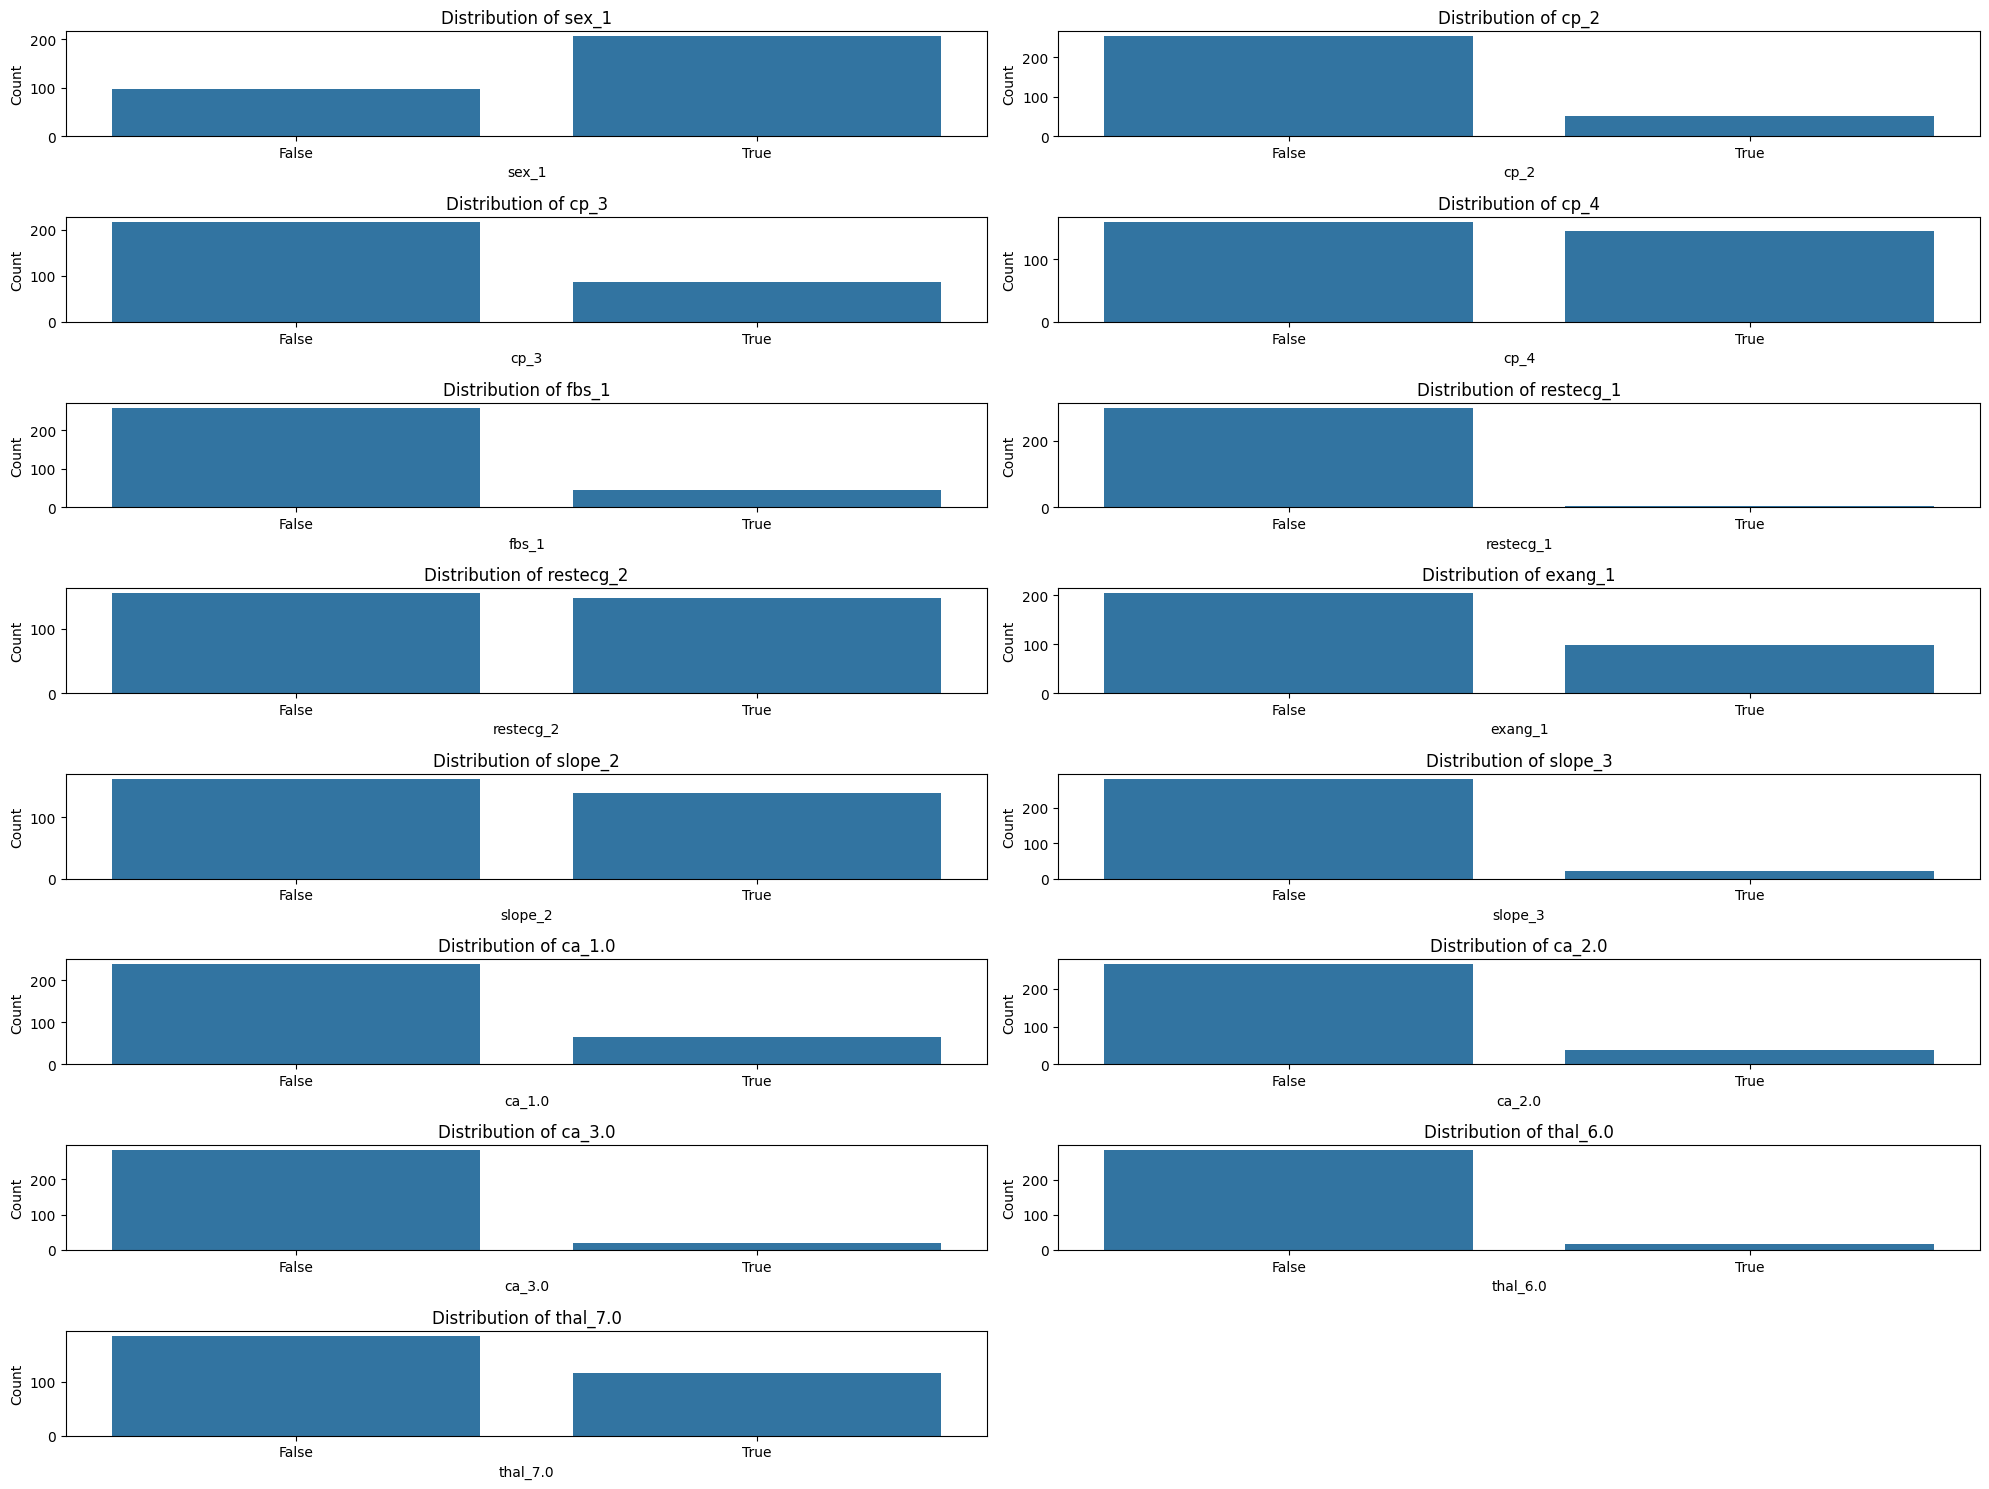

In [98]:
import math

# Identify one-hot encoded categorical columns
one_hot_cols = [col for col in df_final.columns if col.startswith(('sex_', 'cp_', 'fbs_', 'restecg_', 'exang_', 'slope_', 'ca_', 'thal_'))]

plt.figure(figsize=(20, 15))
for i, col in enumerate(one_hot_cols):
    # Adjusting to a maximum of 2 plots per row
    plt.subplot(math.ceil(len(one_hot_cols)/2), 2, i + 1)
    sns.countplot(x=col, data=df_final)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### 4.2.3 Correlation Matrix

A correlation matrix helps us understand the linear relationships between all features and the target variable. A heatmap is a great way to visualize this matrix.

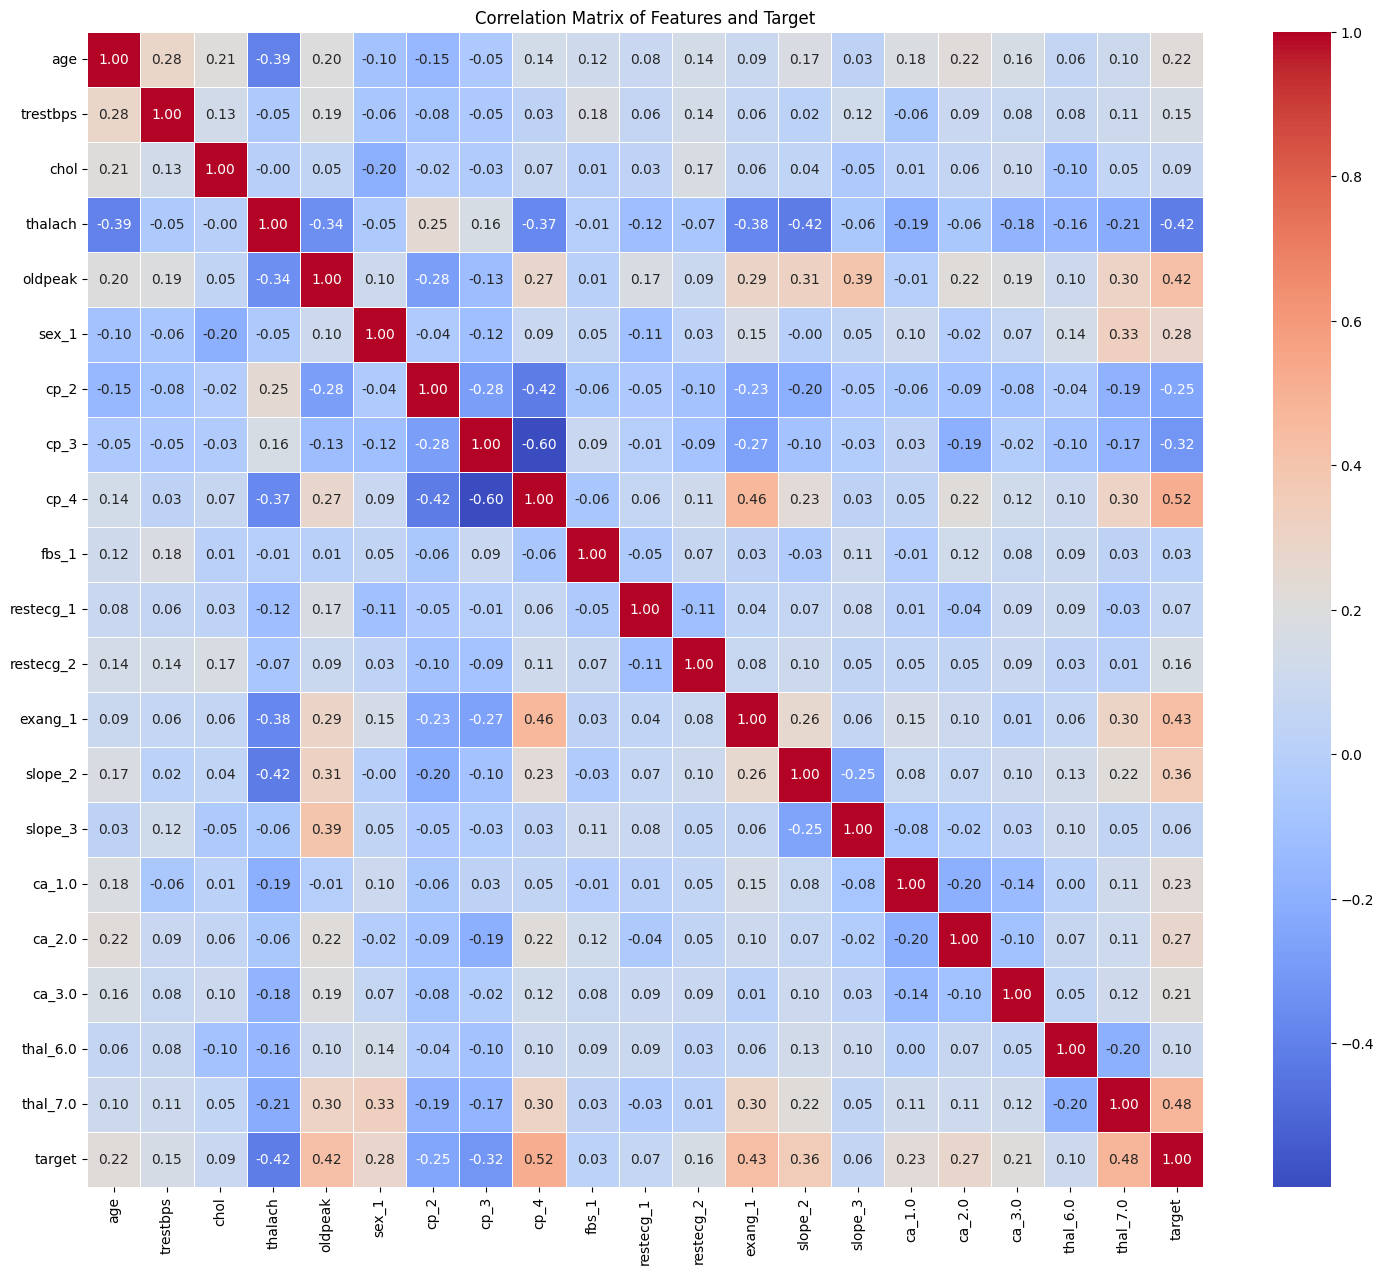

In [99]:
# Convert boolean columns to integer (0 or 1) for correlation calculation
df_corr = df_final.copy()
for col in df_corr.select_dtypes(include='bool').columns:
    df_corr[col] = df_corr[col].astype(int)

plt.figure(figsize=(18, 15))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features and Target')
plt.show()

#### 4.2.4 Relationship Between Numerical Features and Target

Box plots or violin plots can illustrate how the distribution of numerical features differs between patients with and without heart disease.

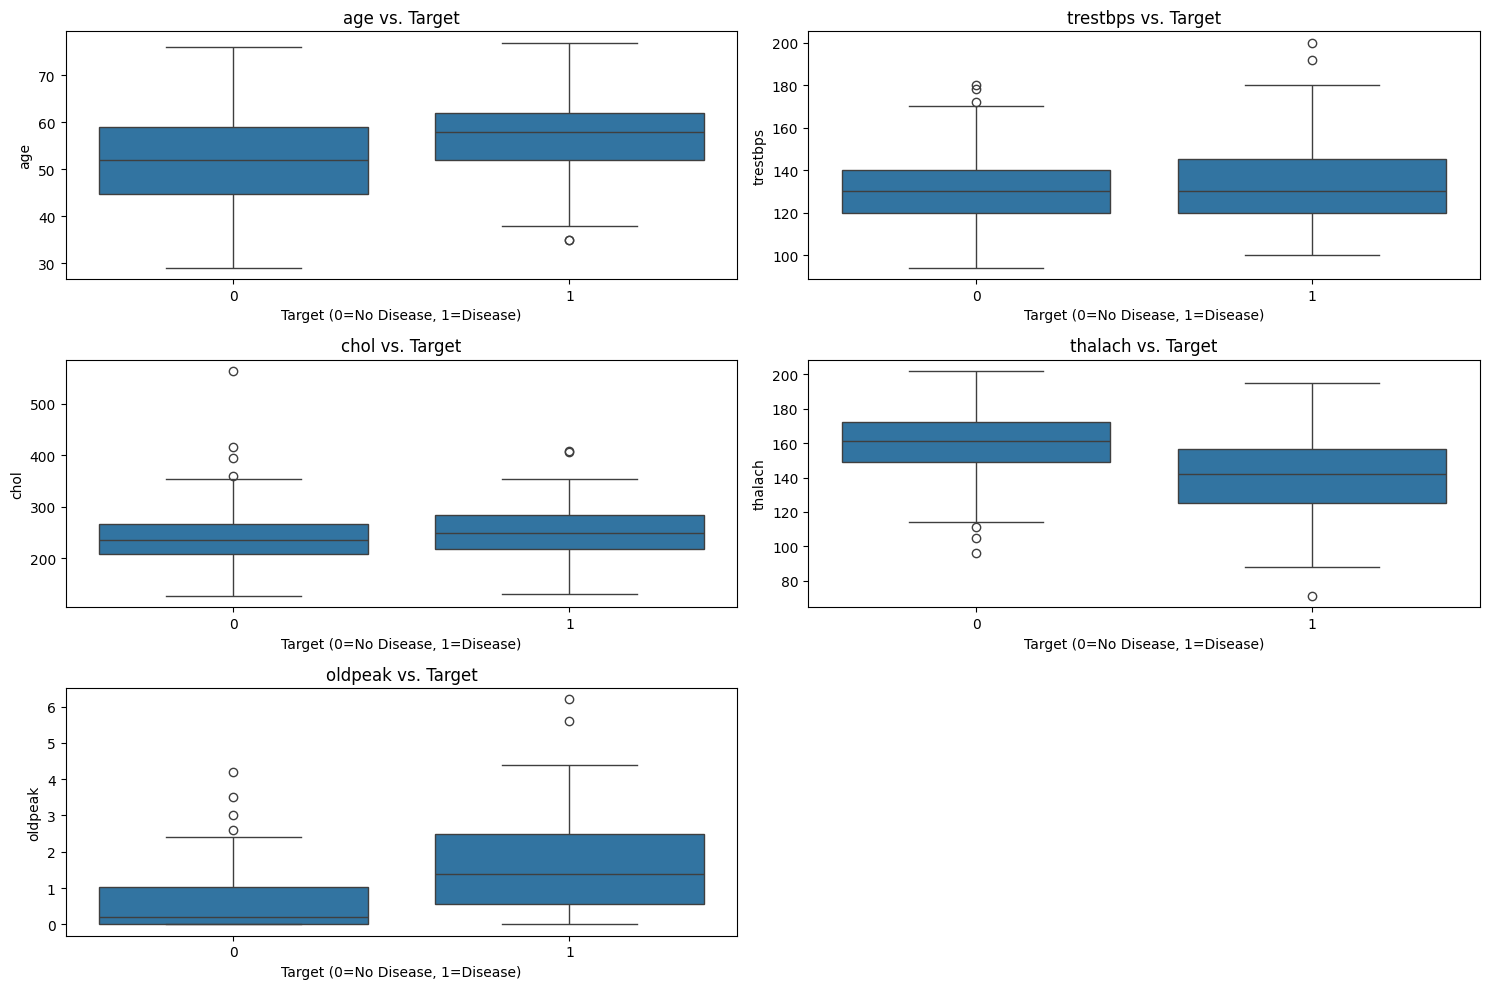

In [100]:
import math

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    # Changing from 2x3 to 2-column layout
    plt.subplot(math.ceil(len(numerical_features)/2), 2, i + 1)
    sns.boxplot(x='target', y=feature, data=df_final)
    plt.title(f'{feature} vs. Target')
    plt.xlabel('Target (0=No Disease, 1=Disease)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### 3.3 Outlier Detection and Handling

Outliers can significantly impact model performance. We will detect outliers in numerical features using the Interquartile Range (IQR) method and then handle them by capping them to reasonable bounds (upper and lower fences).

In [101]:
print("Descriptive statistics before outlier handling:")
display(df_final[numerical_features].describe())

# Outlier Detection and Capping using IQR
for feature in numerical_features:
    Q1 = df_final[feature].quantile(0.25)
    Q3 = df_final[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_final[(df_final[feature] < lower_bound) | (df_final[feature] > upper_bound)]
    print(f"\nOutliers detected in '{feature}': {len(outliers)} instances")

    # Cap outliers
    df_final[feature] = df_final[feature].clip(lower=lower_bound, upper=upper_bound)

print("\nDescriptive statistics after outlier handling (capping):")
display(df_final[numerical_features].describe())

Descriptive statistics before outlier handling:


,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000



Outliers detected in 'age': 0 instances

Outliers detected in 'trestbps': 9 instances

Outliers detected in 'chol': 5 instances

Outliers detected in 'thalach': 1 instances

Outliers detected in 'oldpeak': 5 instances

Descriptive statistics after outlier handling (capping):


,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.346535,245.584158,149.652640,1.024422
std,9.038662,16.648749,47.558803,22.731735,1.110127
min,29.000000,94.000000,126.000000,84.750000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,170.000000,371.000000,202.000000,4.000000


### 4.3 Comprehensive Exploratory Data Analysis

This section presents a structured Exploratory Data Analysis (EDA) of the Heart Disease dataset, organized into univariate, bivariate, and multivariate analyses to extract meaningful insights and prepare the data for modeling.

#### 4.3.1 Univariate Analysis (Single Variable)

Univariate analysis helps us understand the distribution and characteristics of individual variables.

#### Target Variable

*   **Plot:** Countplot of `target`
*   **Goal:** Check class balance

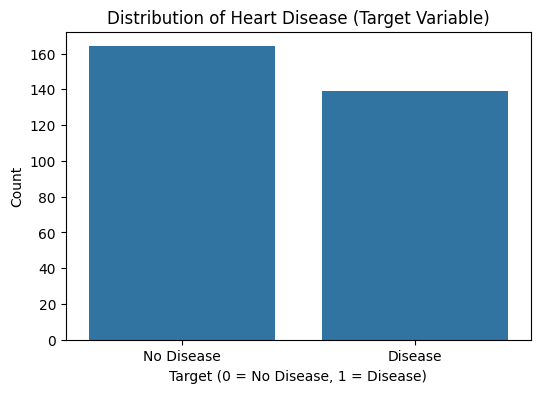

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_final)
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Disease', 'Disease'])
plt.show()
# Insight: The target variable shows a relatively balanced distribution, which is beneficial for model training and avoids issues of class imbalance.

##### 4.3.1.1 Numerical Features

*   **Features:** `age`, `trestbps`, `chol`, `thalach`, `oldpeak`
*   **Plots:** Histogram with KDE, Boxplot
*   **Goal:** Identify distribution shape (normal/skewed), detect outliers

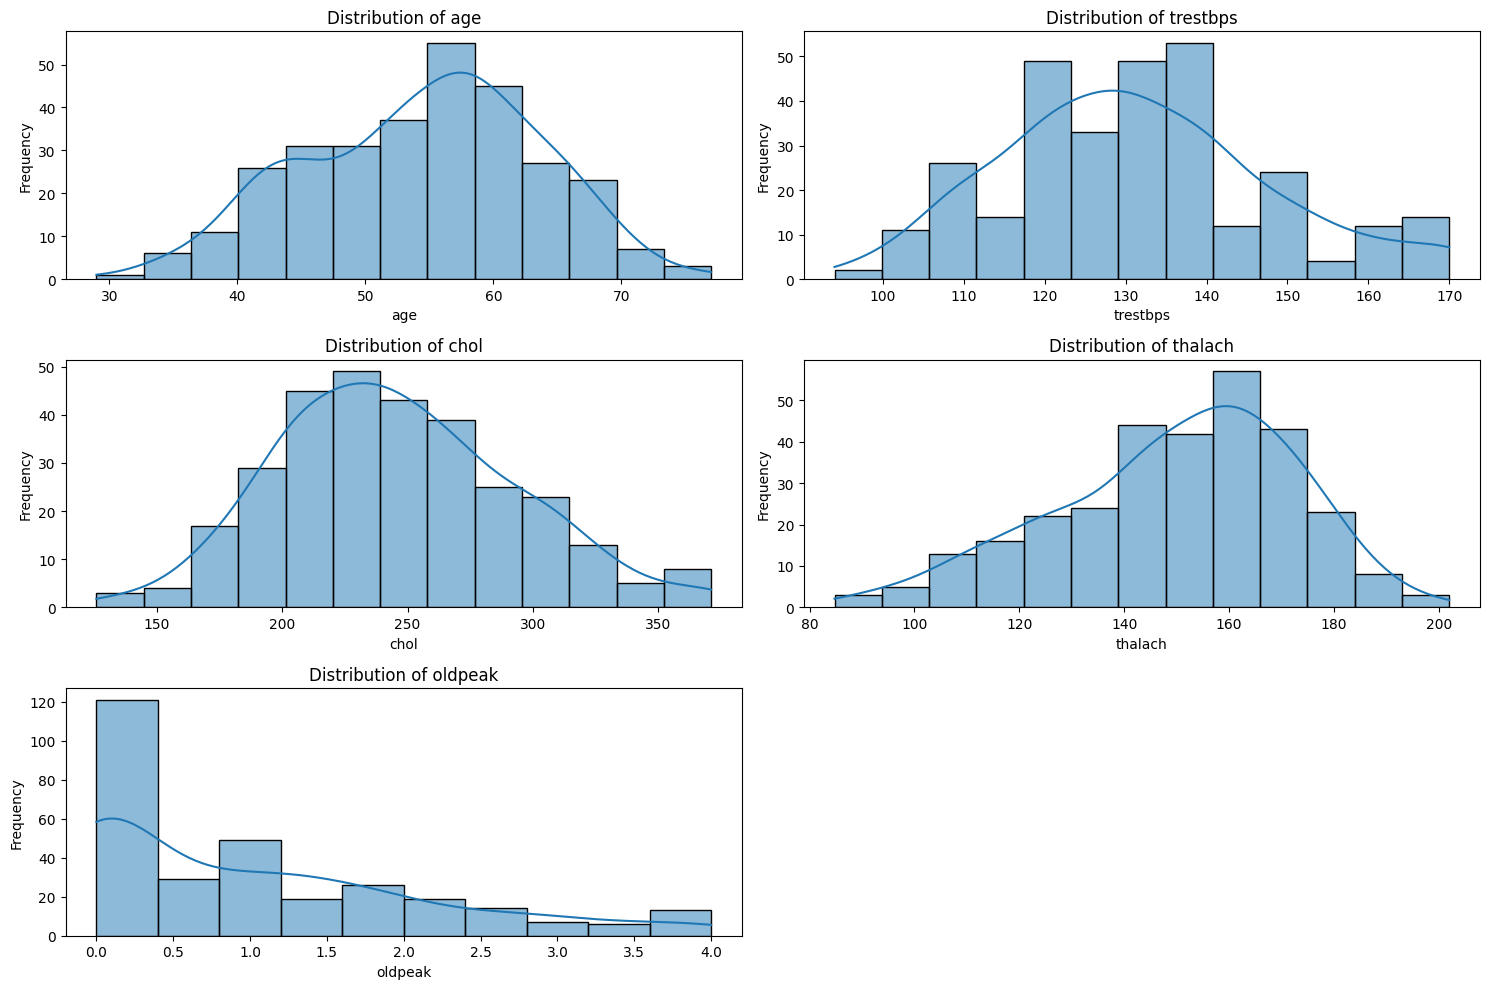

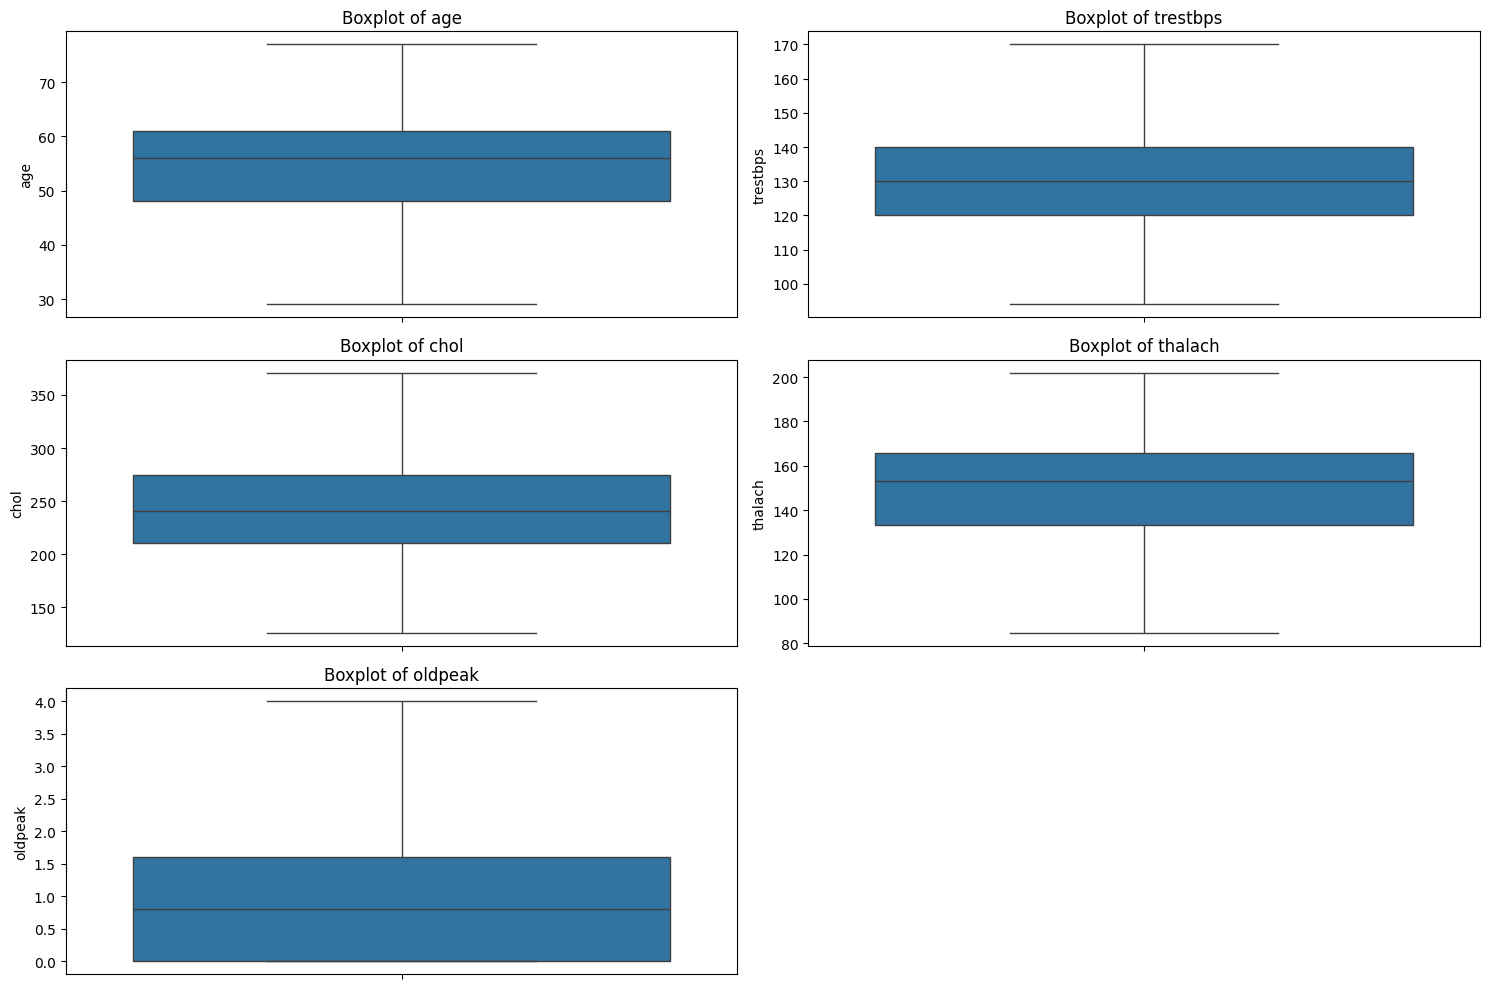

In [103]:
import math

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Histograms with KDE (2 plots per row)
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(math.ceil(len(numerical_features)/2), 2, i + 1)
    sns.histplot(df_final[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Boxplots (2 plots per row)
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(math.ceil(len(numerical_features)/2), 2, i + 1)
    sns.boxplot(y=df_final[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

##### 4.3.1.2 Categorical Features (Original, before One-Hot Encoding)

*   **Features:** `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`
*   **Plot:** Countplot for each
*   **Goal:** Understand category distribution, detect rare or imbalanced categories

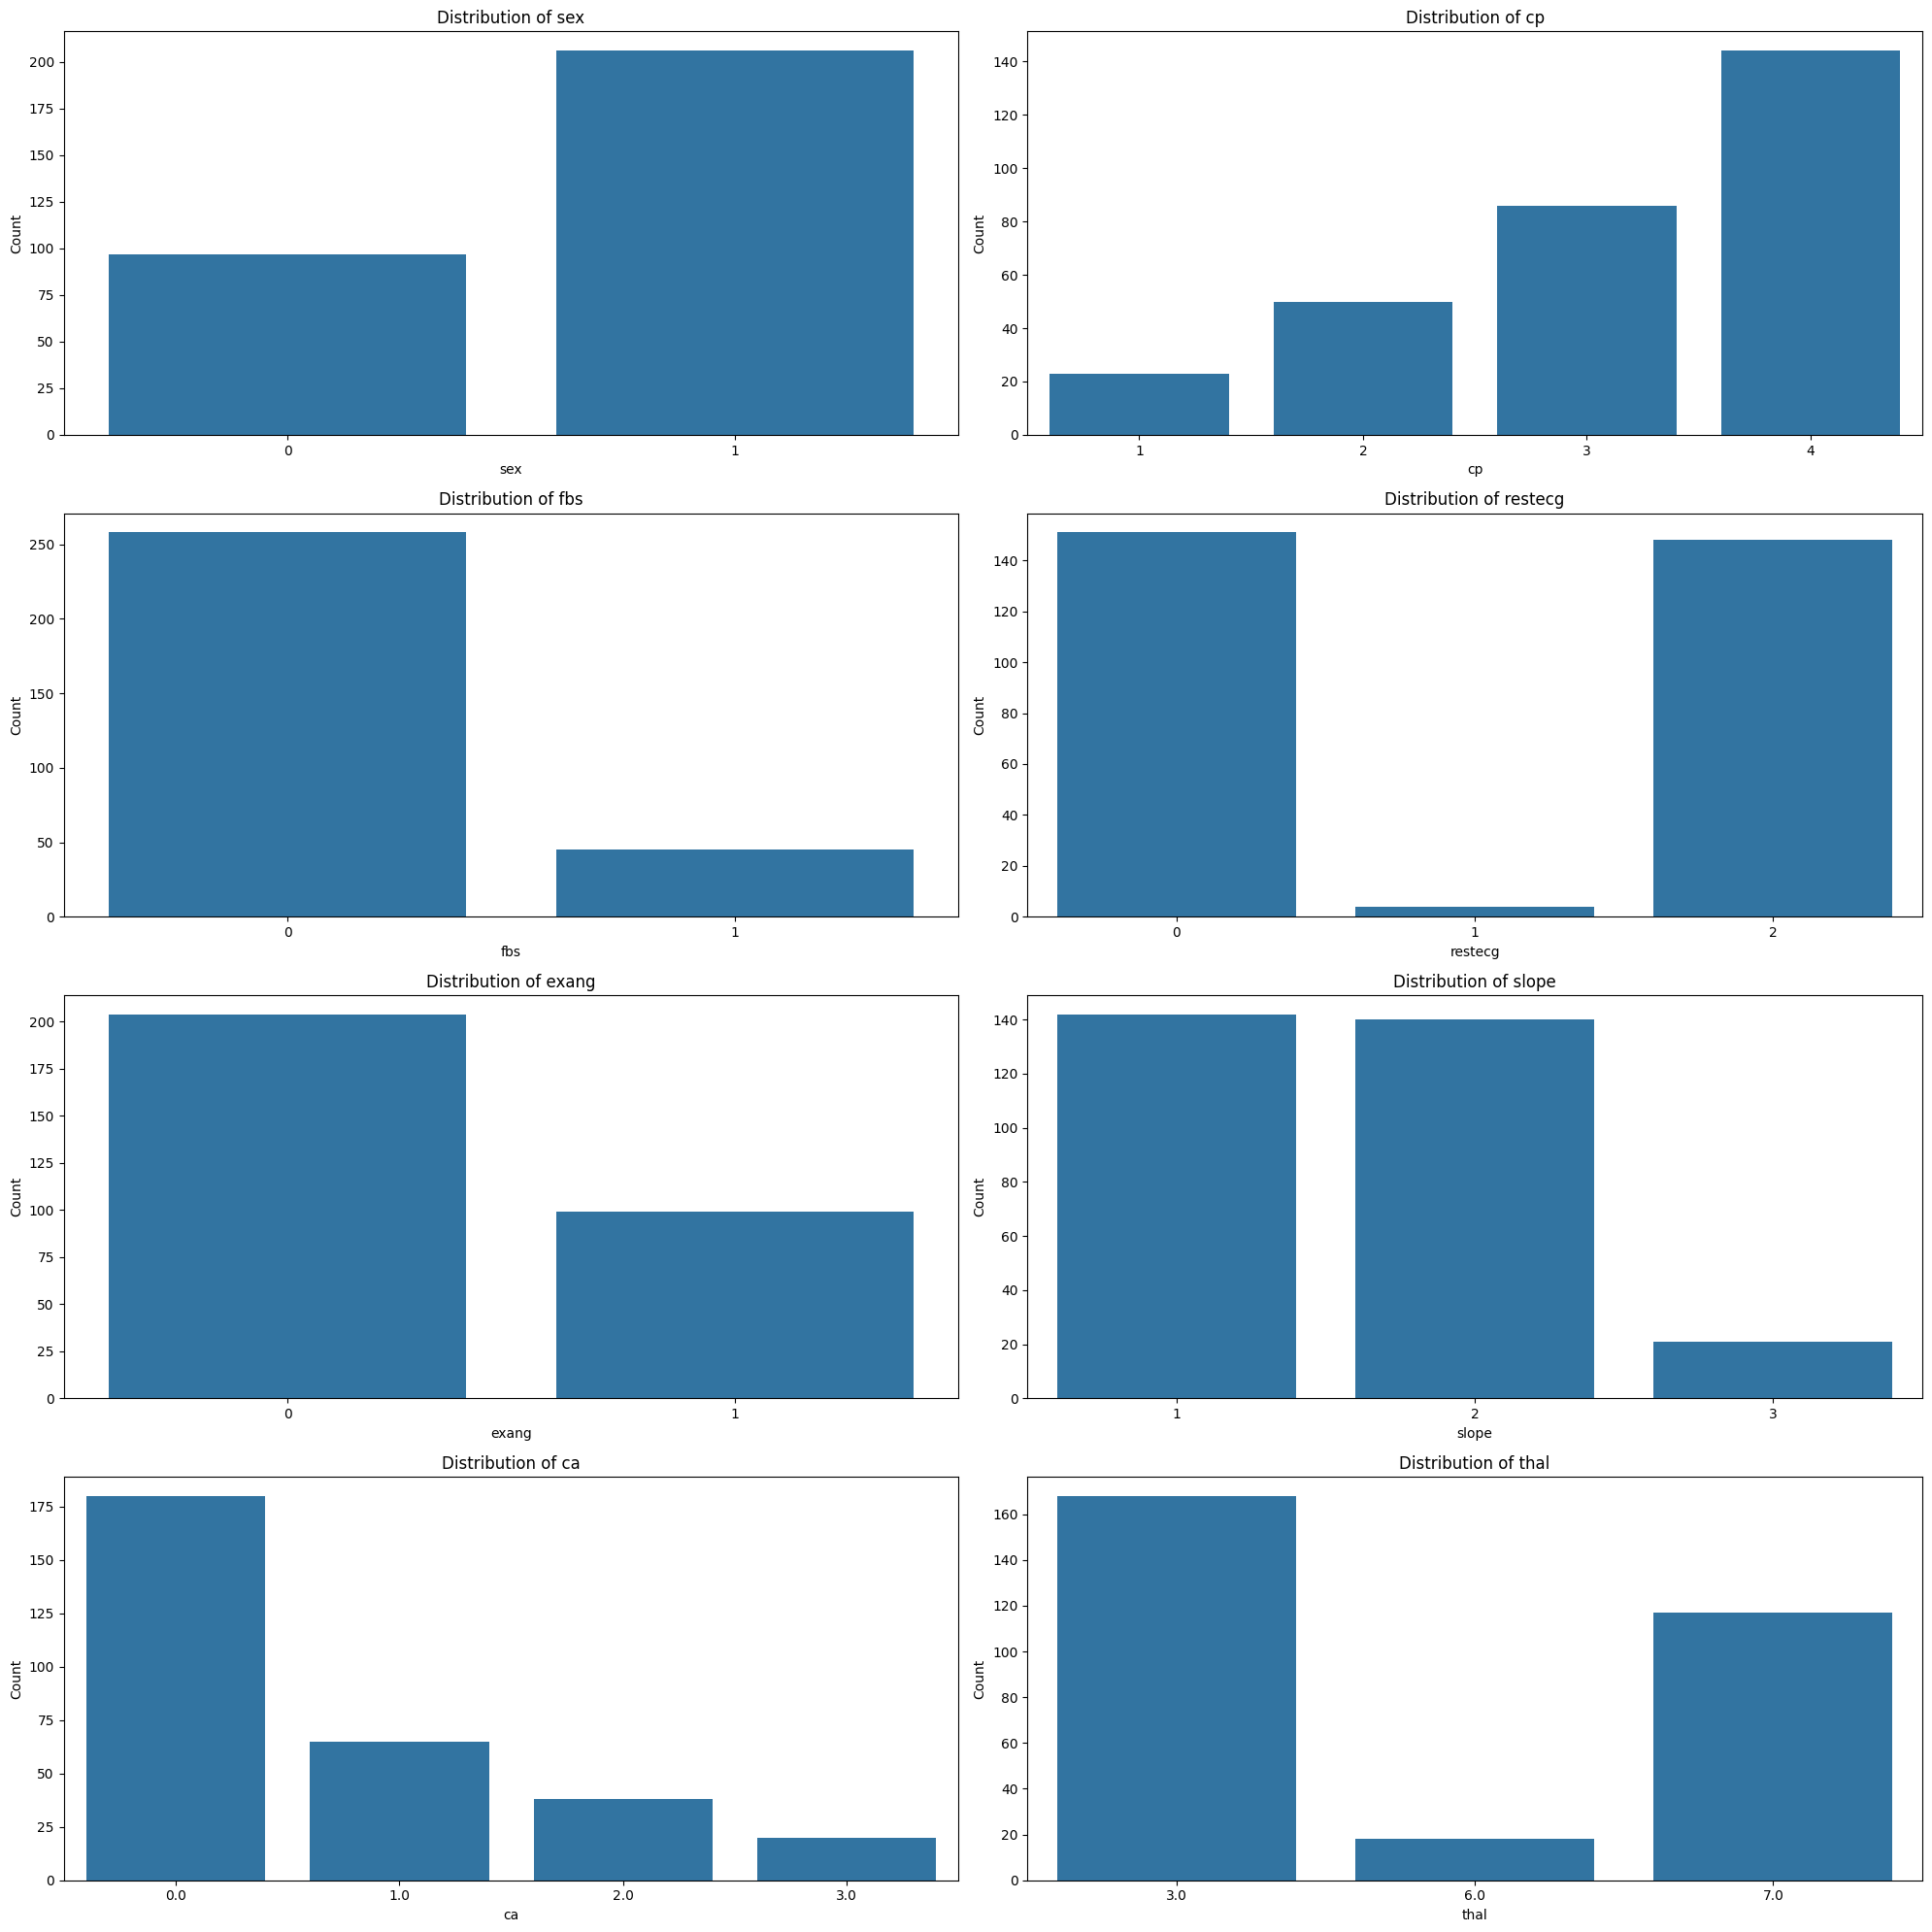

In [104]:
import math

original_categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plt.figure(figsize=(20, 20))
for i, feature in enumerate(original_categorical_features):
    plt.subplot(math.ceil(len(original_categorical_features)/2), 2, i + 1)
    sns.countplot(x=feature, data=df)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()
# Insight: 'sex' shows more males than females. 'cp' type 4 (asymptomatic) is the most frequent. Some categories like 'fbs'=1 and 'restecg'=2 are relatively rare.

#### 4.3.2 Bivariate Analysis (Feature vs Target)

Bivariate analysis explores the relationship between individual features and the target variable.

##### 4.3.2.1 Numerical vs Target

*   **Pairs:** (`age`, `target`), (`trestbps`, `target`), (`chol`, `target`), (`thalach`, `target`), (`oldpeak`, `target`)
*   **Plot:** Boxplot or Violin plot
*   **Goal:** Compare distributions across target classes, identify strong predictors

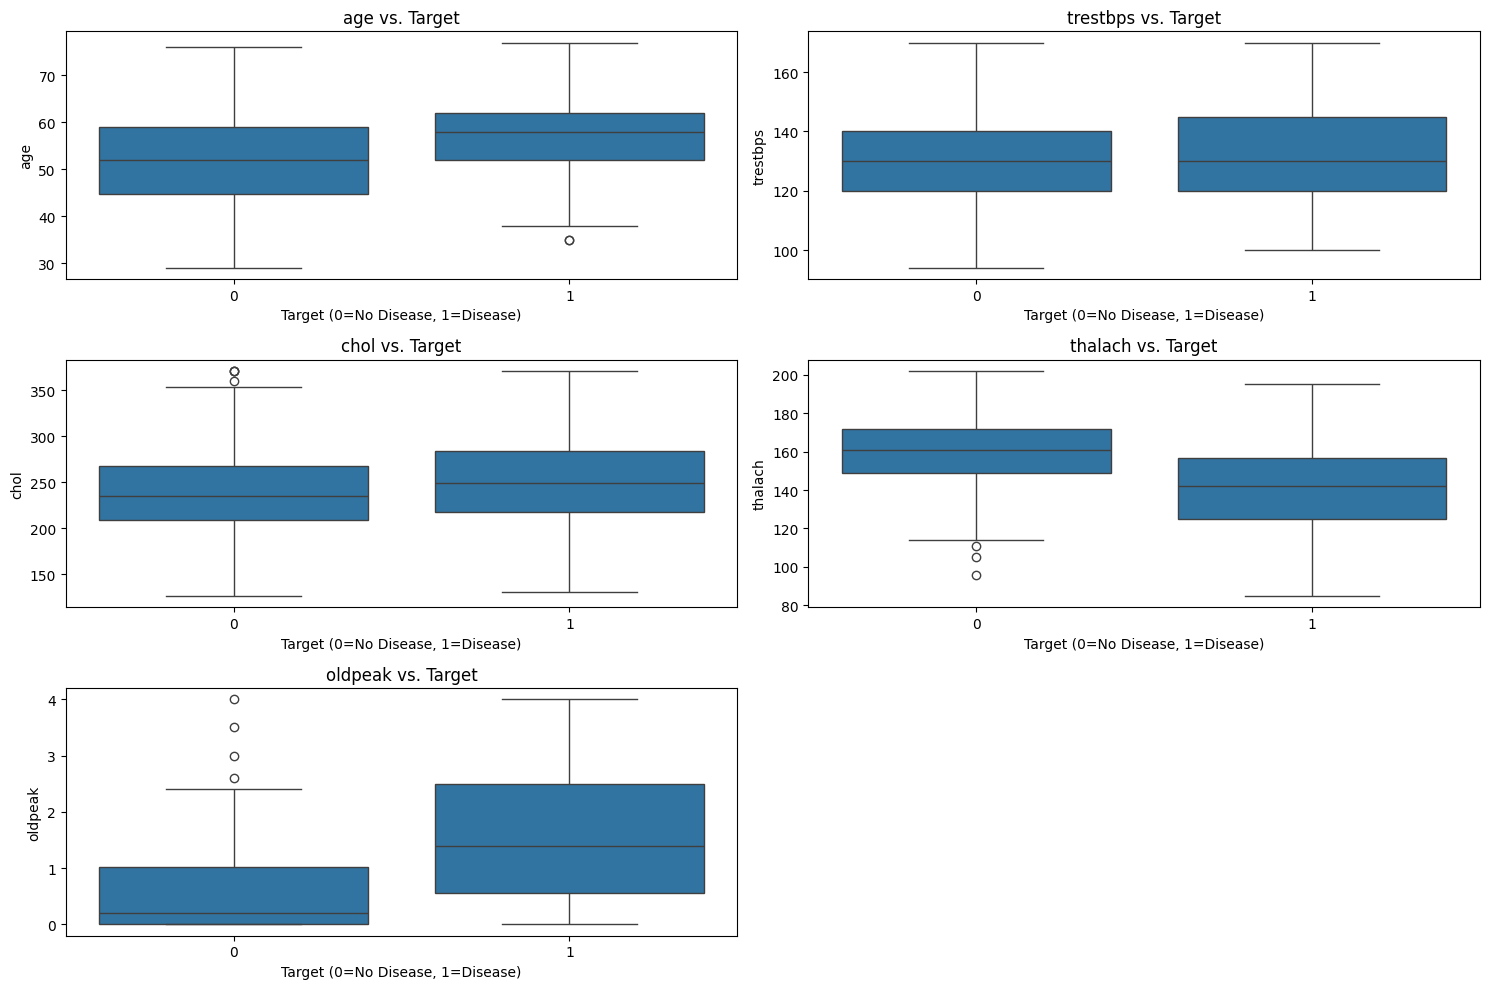

In [105]:
import math

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(math.ceil(len(numerical_features)/2), 2, i + 1)
    sns.boxplot(x='target', y=feature, data=df_final)
    plt.title(f'{feature} vs. Target')
    plt.xlabel('Target (0=No Disease, 1=Disease)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()
# Insight: Patients with heart disease tend to have lower 'thalach' and higher 'oldpeak' values. 'age', 'trestbps', and 'chol' show some differences but with more overlap between target classes.

##### 4.3.2.2 Categorical vs Target (Original Categories)

*   **Pairs:** All original categorical features vs `target`
*   **Plot:** Countplot with `hue = target`
*   **Goal:** Identify which categories are associated with higher risk

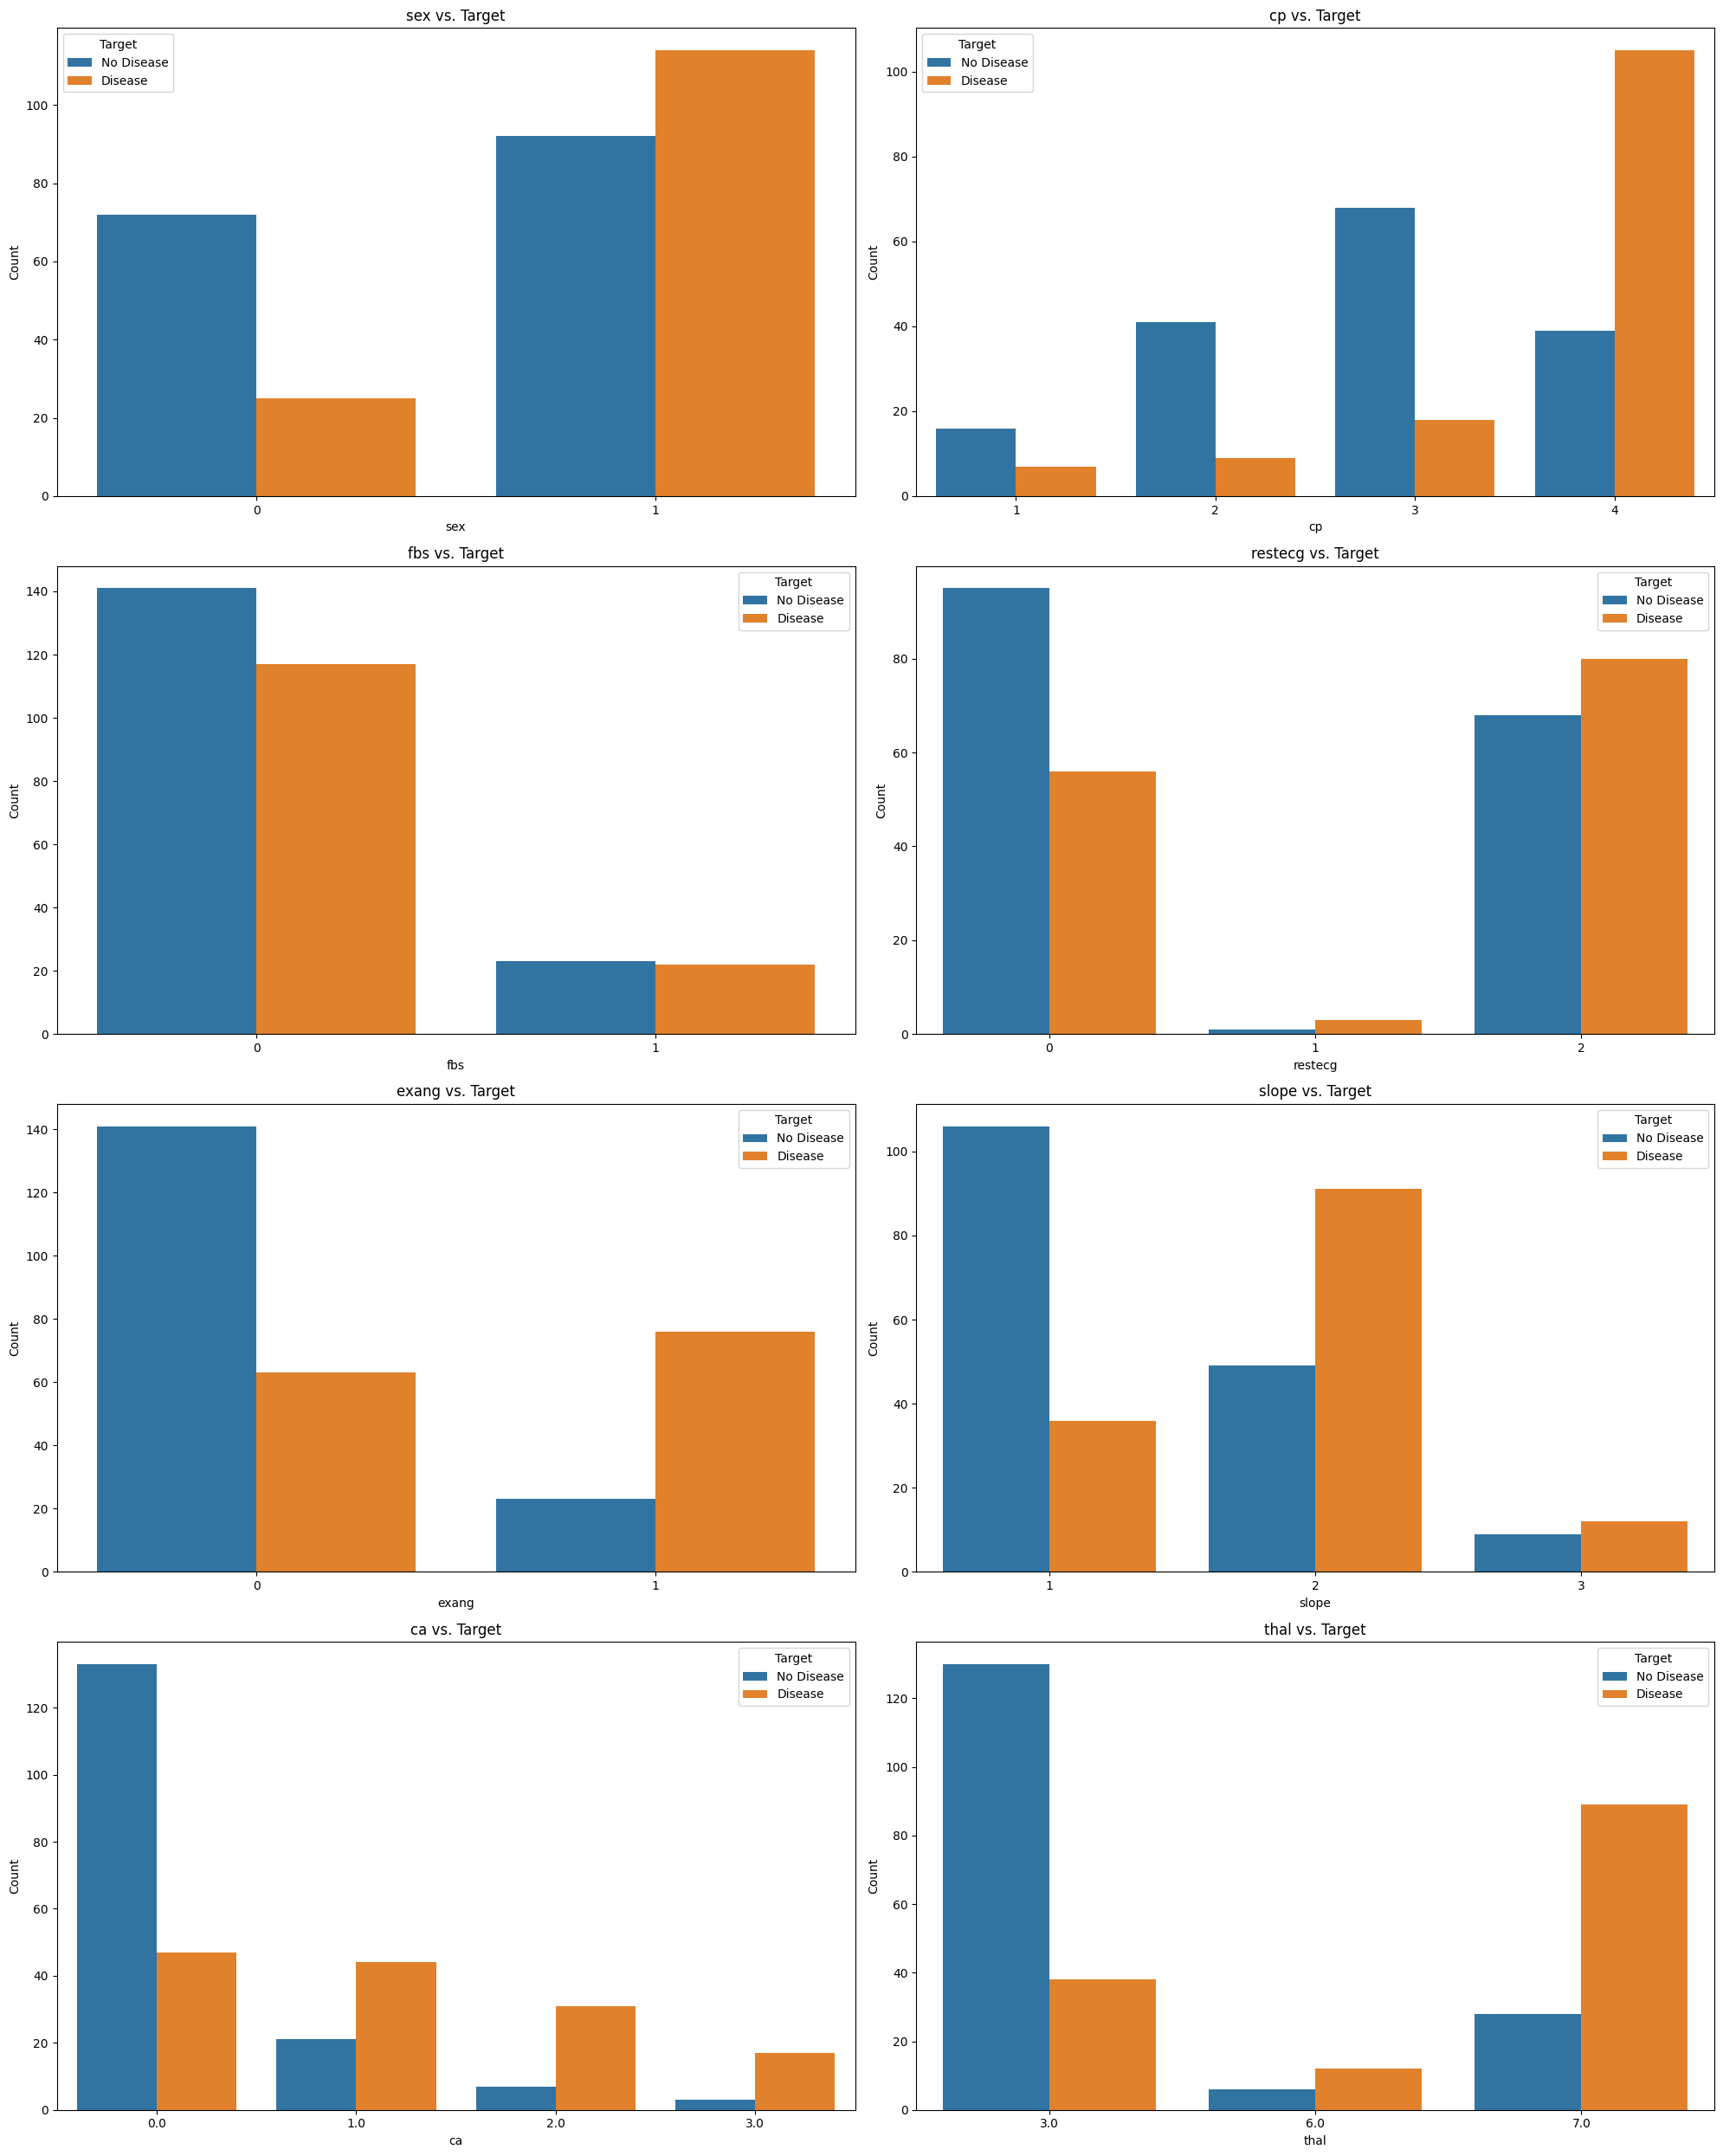

In [106]:
import math

# We use 'df' here because it contains the original categorical names ('sex', 'cp', etc.)
# We add the 'target' from our binarization process for the hue
df_eda = df.copy()
df_eda['target'] = df_final['target']

plt.figure(figsize=(20, 25))
for i, feature in enumerate(original_categorical_features):
    plt.subplot(math.ceil(len(original_categorical_features)/2), 2, i + 1)
    sns.countplot(x=feature, hue='target', data=df_eda)
    plt.title(f'{feature} vs. Target')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

#### 4.3.3 Bivariate Analysis (Feature vs Feature)

This section examines relationships between different features themselves.

##### 4.3.3.1 Numerical vs Numerical

*   **Pairs:** (`age`, `thalach`), (`age`, `trestbps`), (`chol`, `trestbps`), (`oldpeak`, `thalach`)
*   **Plot:** Scatter plot
*   **Goal:** Detect relationships and trends, identify correlations

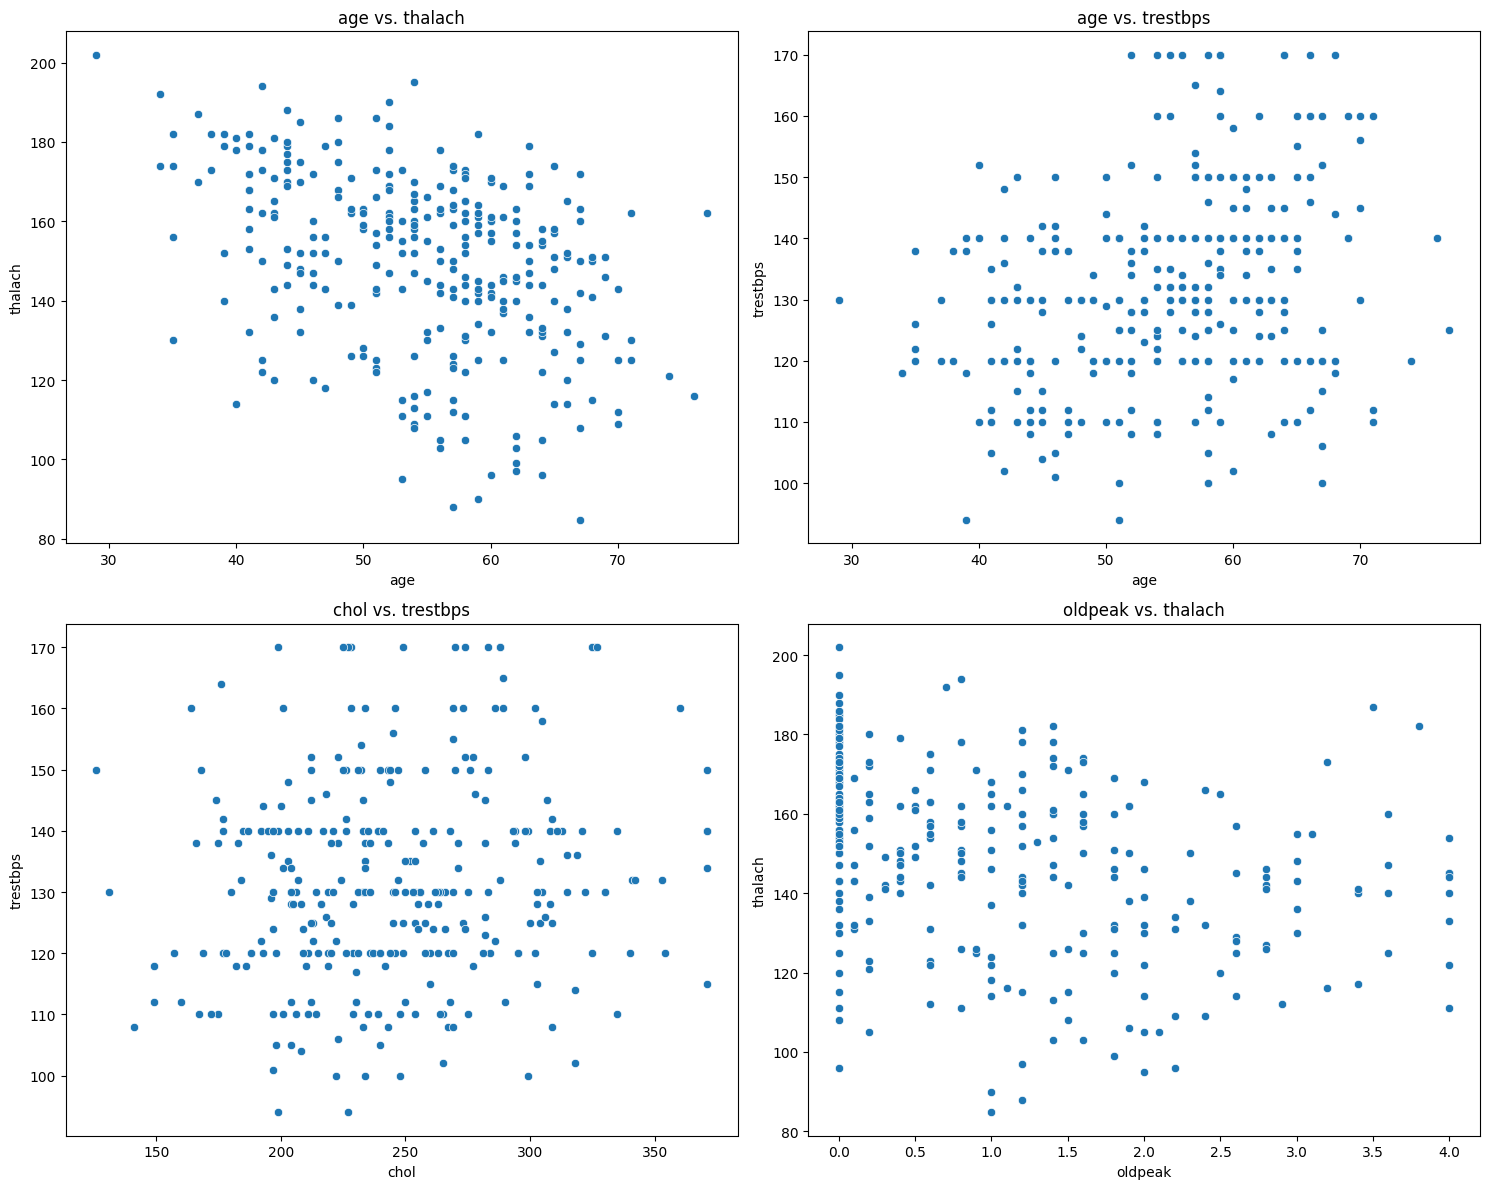

In [107]:
pair_plots_num = [
    ('age', 'thalach'),
    ('age', 'trestbps'),
    ('chol', 'trestbps'),
    ('oldpeak', 'thalach')
]

plt.figure(figsize=(15, 12))
for i, (x_col, y_col) in enumerate(pair_plots_num):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=x_col, y=y_col, data=df_final)
    plt.title(f'{x_col} vs. {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
plt.tight_layout()
plt.show()
# Insight: Some relationships are visible, e.g., a slight negative trend between 'age' and 'thalach'. Other pairs show a general spread without strong linear trends.

#### 4.3.4 Multivariate Analysis

Multivariate analysis considers the relationships among three or more variables simultaneously.

##### 4.3.4.1 Correlation Matrix

*   **Variables:** All features and `target` (converted boolean columns to int)
*   **Plot:** Heatmap
*   **Goal:** Identify feature correlations, detect multicollinearity

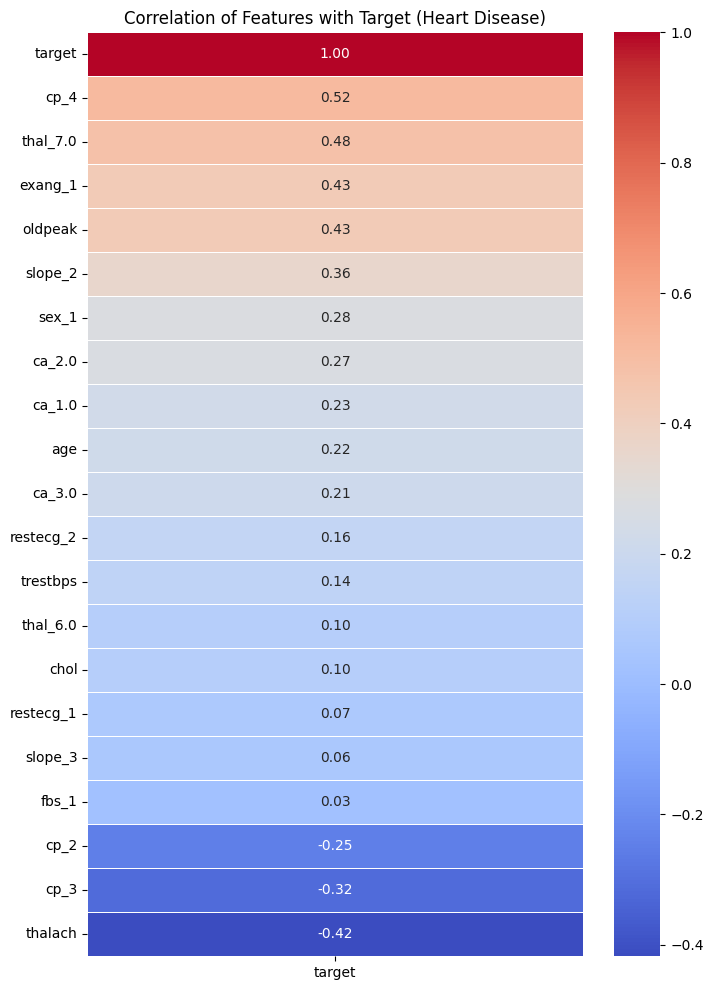

In [108]:
df_corr_multi = df_final.copy()
for col in df_corr_multi.select_dtypes(include='bool').columns:
    df_corr_multi[col] = df_corr_multi[col].astype(int)

# Calculate correlation of all features with the target variable
correlations = df_corr_multi.corr()[['target']].sort_values(by='target', ascending=False)

plt.figure(figsize=(8, 12))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation of Features with Target (Heart Disease)')
plt.show()
# Insight: This focused heatmap reveals that features like cp_4, oldpeak, and ca_2.0 are strongly positively correlated with heart disease, while thalach shows a significant negative correlation.

##### 4.3.4.2 Pairplot

*   **Features:** `age`, `thalach`, `oldpeak`, `chol`, `target`
*   **Plot:** Pairplot with `hue = target`
*   **Goal:** Visualize interactions and class separability

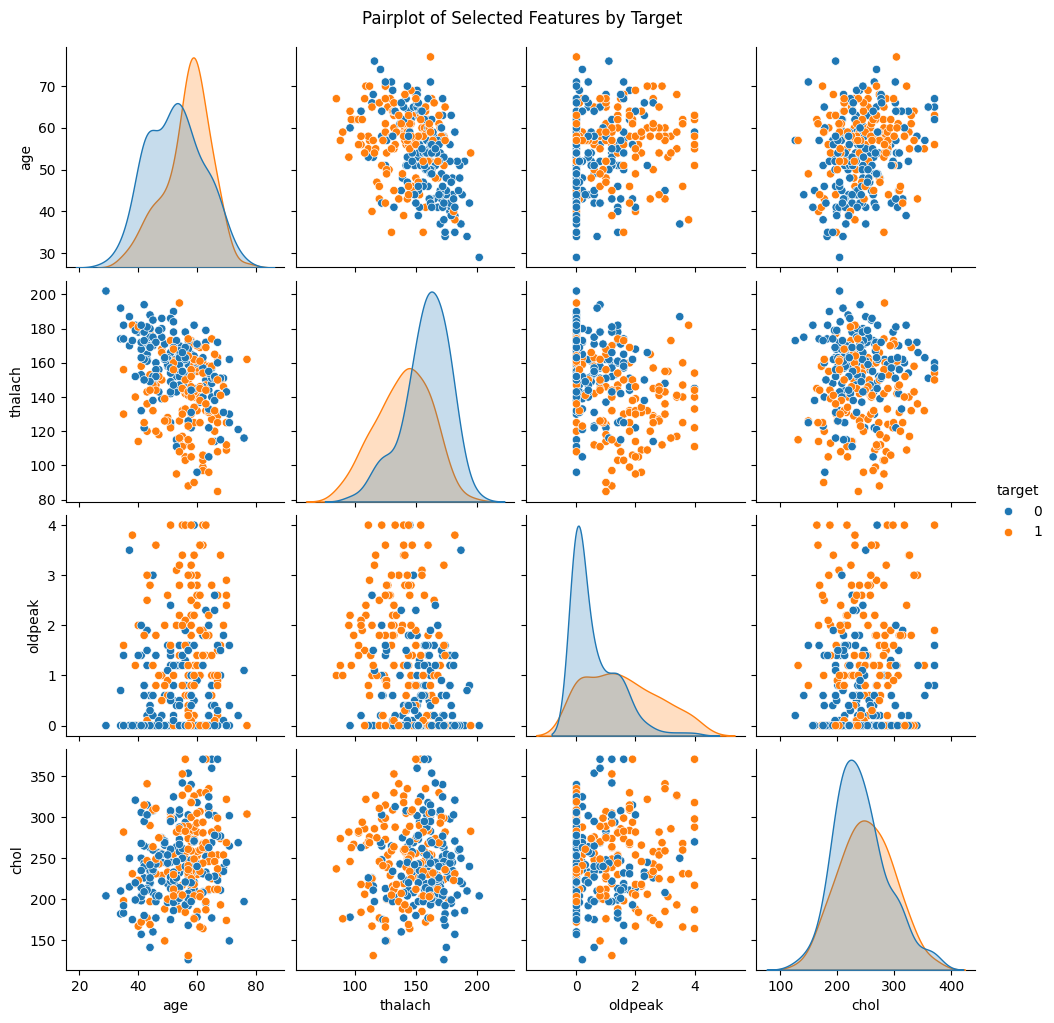

In [109]:
selected_features_for_pairplot = ['age', 'thalach', 'oldpeak', 'chol', 'target']
sns.pairplot(df_final[selected_features_for_pairplot], hue='target', diag_kind='kde')
plt.suptitle('Pairplot of Selected Features by Target', y=1.02) # Adjust suptitle position
plt.show()
# Insight: The pairplot shows how different features interact and how well the 'No Disease' and 'Disease' classes separate across various combinations of these features. Overlap is visible, but distinct clusters are also present.

##### 4.3.4.3 3-Variable Interaction

*   **Pairs:** (`age`, `thalach`, `target`), (`oldpeak`, `thalach`, `target`)
*   **Plot:** Scatter plot with color encoding for target
*   **Goal:** Understand combined feature influence on prediction

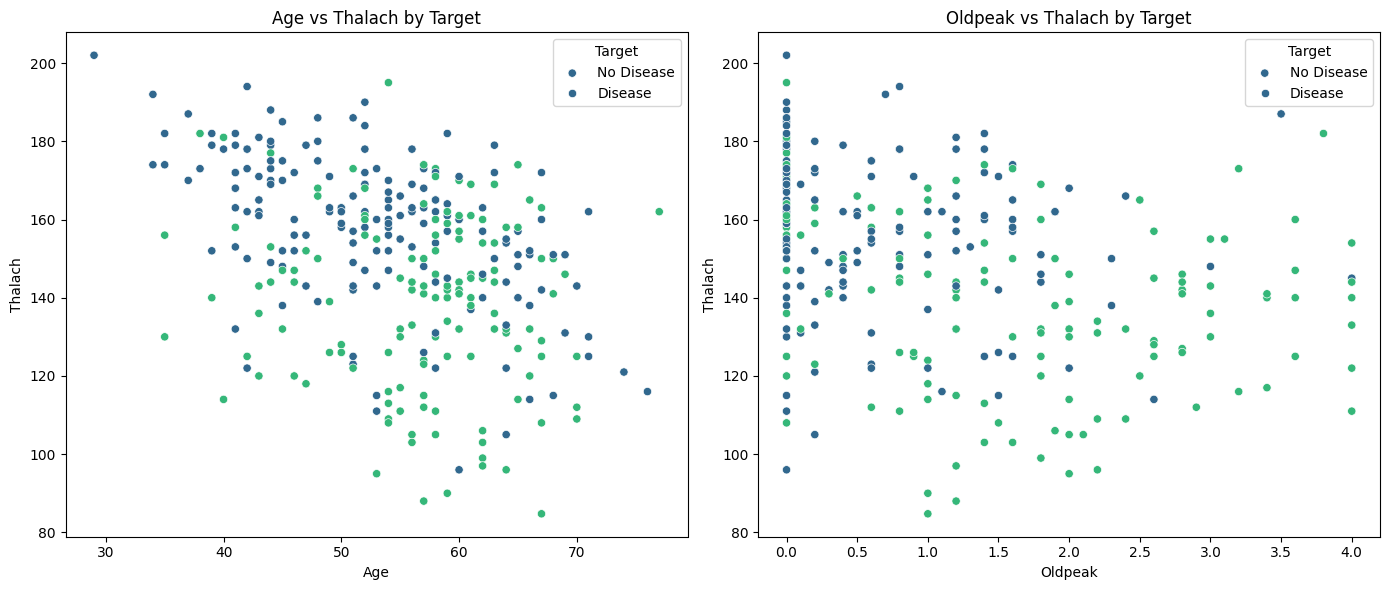

In [110]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='age', y='thalach', hue='target', data=df_final, palette='viridis')
plt.title('Age vs Thalach by Target')
plt.xlabel('Age')
plt.ylabel('Thalach')
plt.legend(title='Target', labels=['No Disease', 'Disease'])

plt.subplot(1, 2, 2)
sns.scatterplot(x='oldpeak', y='thalach', hue='target', data=df_final, palette='viridis')
plt.title('Oldpeak vs Thalach by Target')
plt.xlabel('Oldpeak')
plt.ylabel('Thalach')
plt.legend(title='Target', labels=['No Disease', 'Disease'])

plt.tight_layout()
plt.show()
# Insight: Lower 'thalach' and higher 'oldpeak' values tend to correlate with 'Disease' across different age groups, suggesting these features are strong indicators even when interacting with other variables.

#### 4.3.5 Outlier & Distribution Focus (Important for Preprocessing)

This section specifically focuses on visualizing outliers and distribution overlaps, which are critical for justifying preprocessing steps.

##### 4.3.5.1 Boxplots for all numerical features

*   **Goal:** Detect extreme values, justify preprocessing steps (IQR capping/removal)

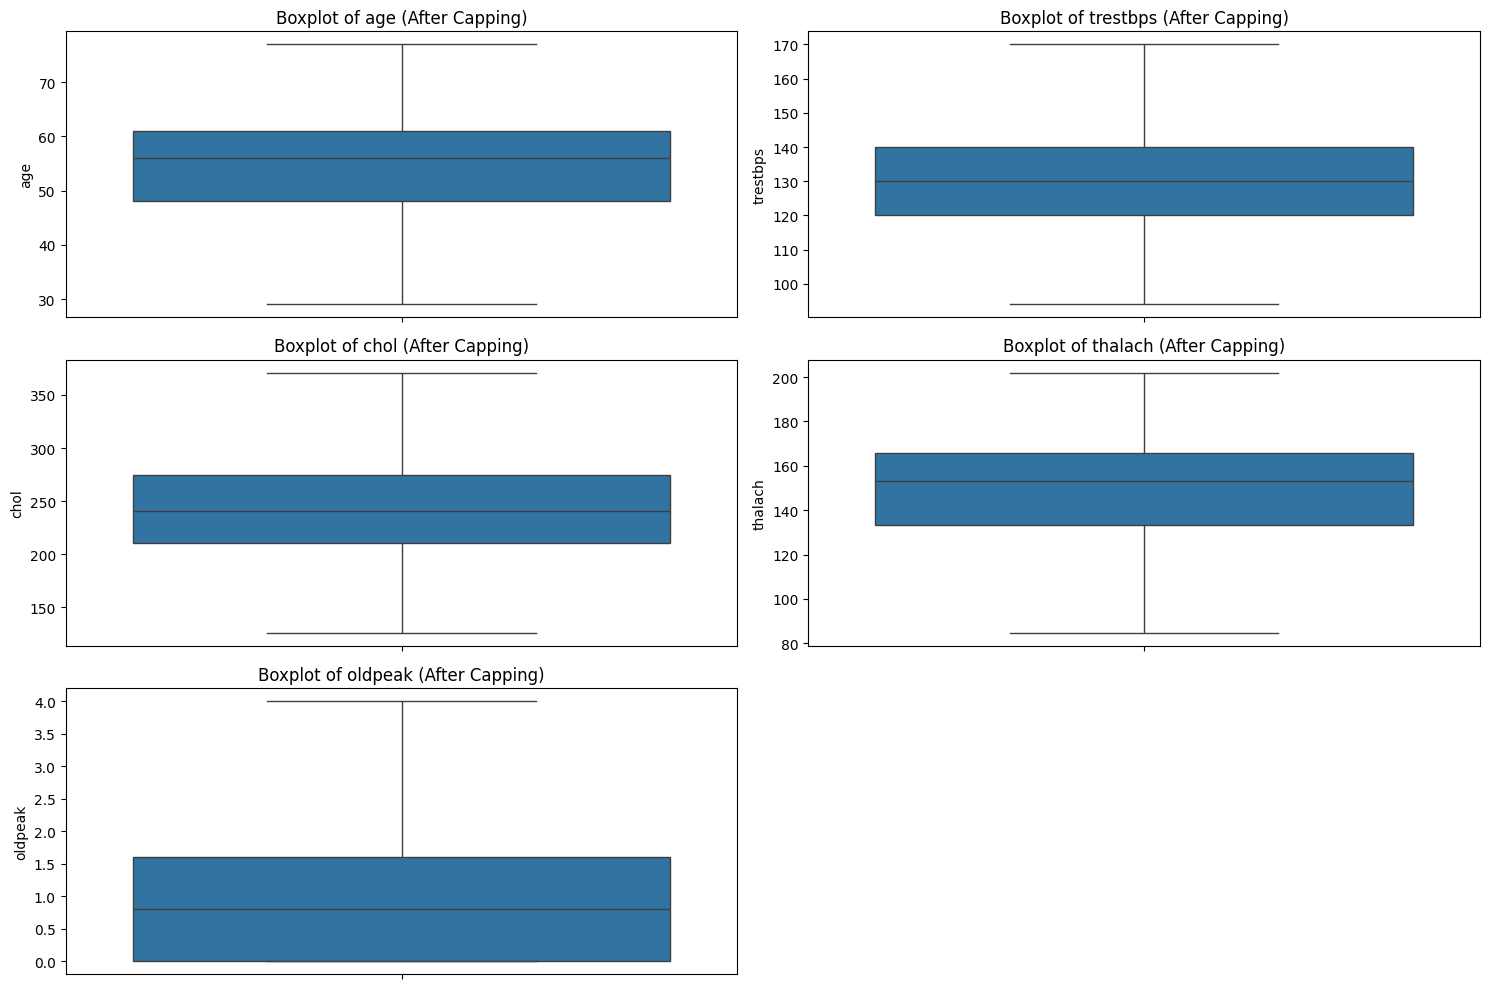

In [111]:
import math

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(math.ceil(len(numerical_features)/2), 2, i + 1)
    sns.boxplot(y=df_final[feature])
    plt.title(f'Boxplot of {feature} (After Capping)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()
# Insight: After capping, extreme outliers are removed, leading to a more compact distribution. Some features still show potential outliers based on boxplot definition, but they are within the IQR-defined fences.

##### 4.3.5.2 KDE plots of key features vs target

*   **Pairs:** (`age`, `target`), (`thalach`, `target`)
*   **Goal:** Check overlap between classes, evaluate feature usefulness

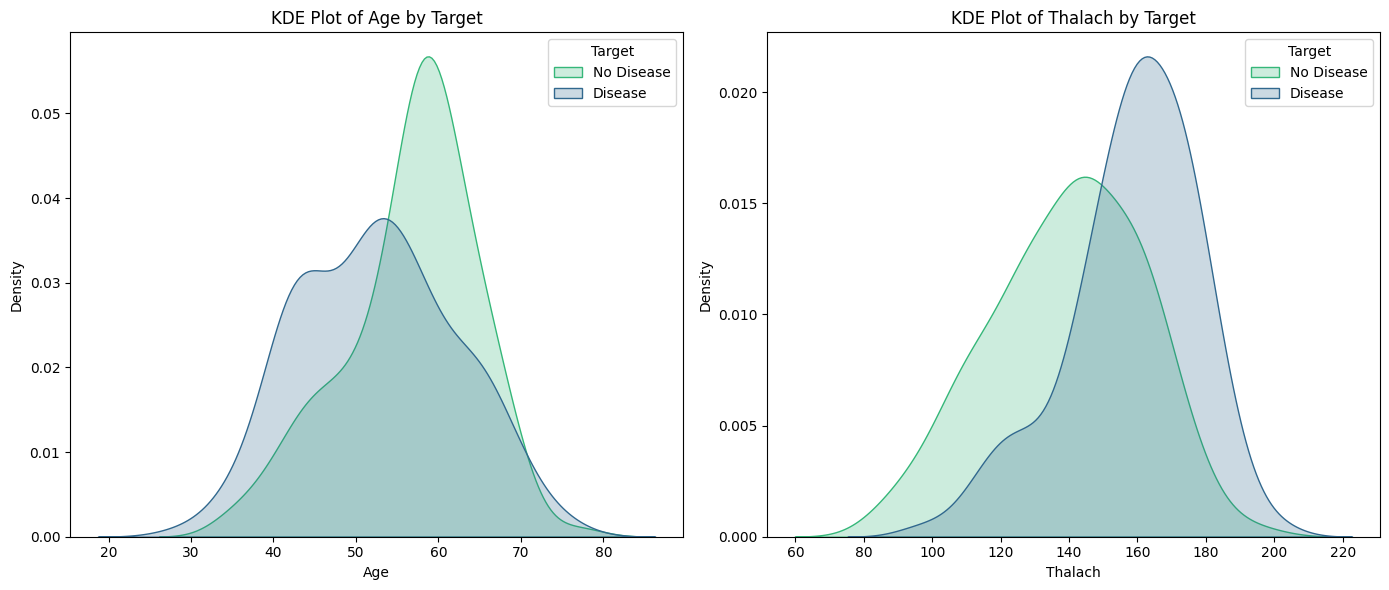

In [112]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(x='age', hue='target', data=df_final, fill=True, common_norm=False, palette='viridis')
plt.title('KDE Plot of Age by Target')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Target', labels=['No Disease', 'Disease'])

plt.subplot(1, 2, 2)
sns.kdeplot(x='thalach', hue='target', data=df_final, fill=True, common_norm=False, palette='viridis')
plt.title('KDE Plot of Thalach by Target')
plt.xlabel('Thalach')
plt.ylabel('Density')
plt.legend(title='Target', labels=['No Disease', 'Disease'])

plt.tight_layout()
plt.show()
# Insight: For 'thalach', there's a clearer separation, with patients having heart disease showing a lower peak heart rate. 'Age' distributions largely overlap, suggesting it's less discriminative on its own.

### 5.1 Data Splitting and Scaling

Before training a machine learning model, it's crucial to split the data into training and testing sets. This allows us to evaluate the model's performance on unseen data and prevent overfitting. Additionally, scaling numerical features is important for many machine learning algorithms, as it standardizes the range of independent variables. This helps to prevent features with larger absolute values from dominating those with smaller absolute values in algorithms that compute distances between data points (e.g., SVMs, K-Nearest Neighbors) or rely on gradient descent (e.g., Neural Networks).

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_final.drop('target', axis=1)
y = df_final['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify numerical columns for scaling (exclude boolean and one-hot encoded columns)
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical columns in the training set
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# Apply scaling to numerical columns in the test set using the scaler fitted on the training data
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nFirst 5 rows of scaled X_train:")
display(X_train.head())

Shape of X_train: (242, 20)
Shape of X_test: (61, 20)
Shape of y_train: (242,)
Shape of y_test: (61,)

First 5 rows of scaled X_train:


,age,trestbps,chol,thalach,oldpeak,sex_1,cp_2,cp_3,cp_4,fbs_1,restecg_1,restecg_2,exang_1,slope_2,slope_3,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
180,-0.729485,-0.398560,0.536644,0.711573,-0.455191,True,False,False,True,False,False,True,False,True,False,False,False,False,False,True
208,0.050166,-0.037318,0.284596,0.221766,-0.927560,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
167,-0.061212,0.083095,0.830701,0.399877,-0.927560,False,True,False,False,True,False,True,True,False,False,True,False,False,False,False
105,-0.061212,-1.361870,1.271786,0.266294,-0.927560,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True
297,0.272924,0.564751,-0.156489,-1.203128,-0.738613,False,False,False,True,False,False,False,True,True,False,False,False,False,False,True


### 5.2 Model Training and Evaluation - Logistic Regression

We will start with a Logistic Regression model, which is a simple yet effective algorithm for binary classification problems. After training the model, we will evaluate its performance on the test set using various metrics such as accuracy, precision, recall, and F1-score to assess its predictive capabilities.

In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Model Evaluation:
Accuracy: 0.8852
Precision: 0.8621
Recall: 0.8929
F1-Score: 0.8772

Confusion Matrix:
[[29  4]
 [ 3 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61



### 5.3 Model Training and Evaluation - Random Forest Classifier

Next, we'll implement a Random Forest Classifier. This ensemble learning method builds multiple decision trees and merges them to get a more accurate and stable prediction. We will train the model and then evaluate its performance using the same metrics as for Logistic Regression.

In [115]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier model
# Using a random_state for reproducibility
# n_estimators is the number of trees in the forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:"
)
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Model Evaluation:
Accuracy: 0.8689
Precision: 0.8333
Recall: 0.8929
F1-Score: 0.8621

Confusion Matrix:
[[28  5]
 [ 3 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



### 5.4 Model Training and Evaluation - XGBoost Classifier

Finally, we will implement an XGBoost Classifier, known for its performance and efficiency, especially in structured data. We'll train this model and evaluate it against the same metrics to compare its predictive power with Logistic Regression and Random Forest.

In [116]:
from xgboost import XGBClassifier

# Initialize and train the XGBoost Classifier model
# Using a random_state for reproducibility
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Classifier Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classifier Model Evaluation:
Accuracy: 0.8525
Precision: 0.8276
Recall: 0.8571
F1-Score: 0.8421

Confusion Matrix:
[[28  5]
 [ 4 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        33
           1       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



### 5.5 Cross-Validation for Robust Evaluation

To ensure our model evaluations are more robust and less dependent on a single train-test split, we will implement K-Fold cross-validation. This technique helps us obtain a more reliable estimate of model performance by repeatedly splitting the data into training and validation sets.

We will use `StratifiedKFold` to maintain the proportion of the target variable in each fold, which is particularly important for imbalanced datasets, although our current dataset seems relatively balanced. We will then apply this to our three models: Logistic Regression, Random Forest, and XGBoost.

In [117]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Prepare the models for cross-validation
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Initialize Stratified K-Fold cross-validation
# n_splits=5 means the data will be split into 5 folds
# shuffle=True ensures the data is shuffled before splitting
# random_state for reproducibility
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-Validation Results (Accuracy):")
for name, model in models.items():
    # Perform cross-validation and get accuracy scores
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    print(f"{name}: Mean Accuracy = {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")


Cross-Validation Results (Accuracy):
Logistic Regression: Mean Accuracy = 0.8481 (+/- 0.0822)
Random Forest: Mean Accuracy = 0.8054 (+/- 0.0470)
XGBoost: Mean Accuracy = 0.7855 (+/- 0.0550)


### 6.1 Comparison of Model Performance

After evaluating our three models (Logistic Regression, Random Forest, and XGBoost) using both standard train-test splits and Stratified K-Fold Cross-Validation, we can compare their performance. Below is a summary of the metrics achieved on the hold-out test set.

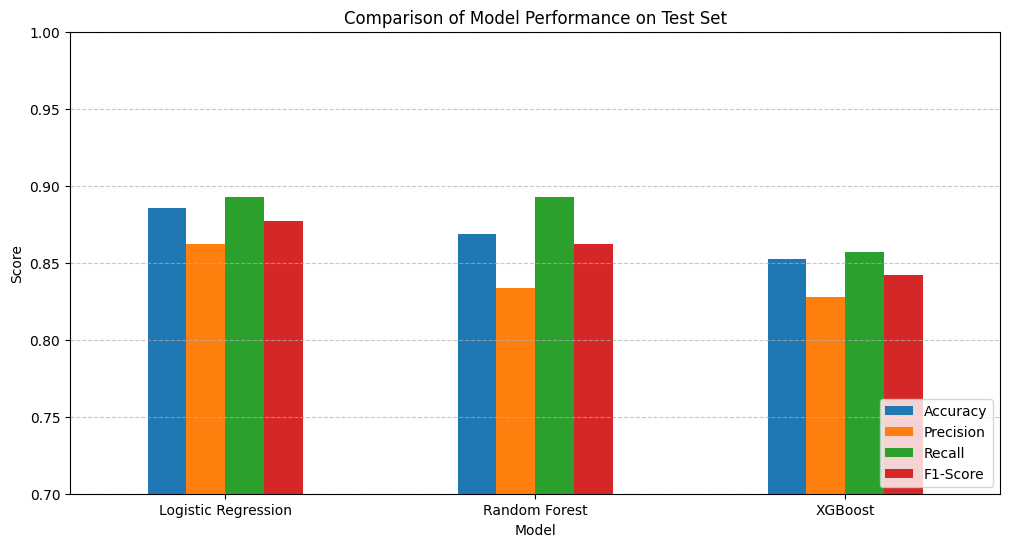

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.885246,0.862069,0.892857,0.877193
1,Random Forest,0.868852,0.833333,0.892857,0.862069
2,XGBoost,0.852459,0.827586,0.857143,0.842105


In [118]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Summarize results from the earlier execution outputs
results_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_log_reg),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_log_reg),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_log_reg),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ]
}

results_df = pd.DataFrame(results_data)

# Plotting the comparison
results_df.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of Model Performance on Test Set')
plt.ylabel('Score')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(results_df)

### 6.3 Confusion Matrix Heatmap for Logistic Regression

To provide a visual understanding of the Logistic Regression model's performance, we'll generate a confusion matrix heatmap. This plot will clearly show the number of true positive, true negative, false positive, and false negative predictions.

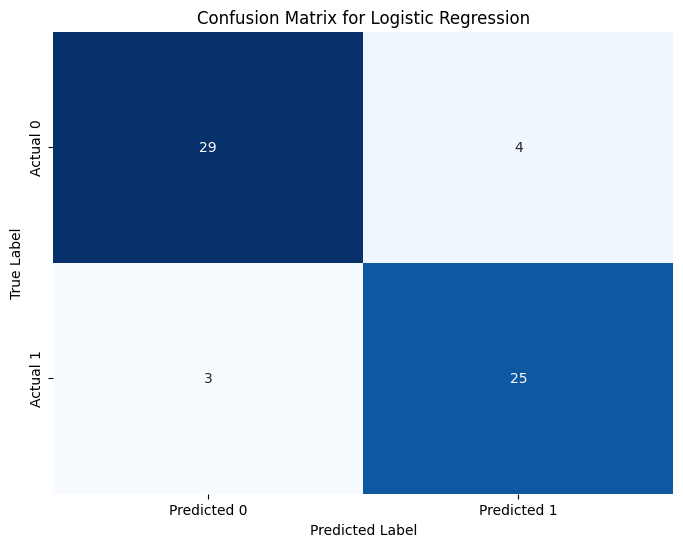

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred_log_reg are already defined from previous cells
cm = confusion_matrix(y_test, y_pred_log_reg)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [120]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
